# 01 — Overpass: Model Gut-Checks

Targeted diagnostics for the 5 physics fixes applied to `TreeCropModel`.

| Plot | What it checks | Fix tested |
|------|---------------|------------|
| 1 | ψ(s) nonlinearity + HR driving force | Fix 1 |
| 2 | Water balance closure | Fixes 2, 3, 5 |
| 3 | Faidherbia single-season trace | Fixes 1, 2, 3 |
| 4 | Shade affects E but not T_crop | Fix 4 |

In [1]:
import nbformat, sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time

# Load class-definition and helper cells from tree.ipynb
_nb = nbformat.read('../tree.ipynb', as_version=4)
for _cell in _nb.cells:
    if _cell.cell_type == 'code' and _cell.get('id', '') in {
        'c23f275b',   # core imports: numpy, farm classes, DataFrame, zeros
        '9adc45cd',   # Tree class
        '2149719d',   # shade_factor()
        '3bed3936',   # TreeCropModel (5 fixes)
        '6jrb65spyt', # _m_yield, _b_yield (Kenya Seed Co. yield regression)
        'b2d38c76',   # run_one_season, season_metrics, _tree_sf
    }:
        # Fix relative paths: notebook runs from exploratory_notebooks/
        src = _cell['source'].replace("'data/", "'../data/").replace('"data/', '"../data/')
        exec(src, globals())

print('Loaded: Tree, TreeCropModel, shade_factor, season_metrics, run_one_season')

plt.rcParams.update({
    'font.size': 10, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'legend.frameon': False,
    'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
def despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Loaded: Tree, TreeCropModel, shade_factor, season_metrics, run_one_season


In [2]:
# Canonical objects used across all plots
np.random.seed(42)

soil  = Soil(texture='loam')
crop  = Crop(soil=soil, lgp=180)
climate = Climate()

tree_faid = Tree(
    Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, leaf_fraction=0.0, soil=soil
)
tree_evgr = Tree(
    Zr=1500, T_MAX=4.0, sw_MPa=-2.0, s_star_MPa=-0.1,
    kc=1.0, canopy_cover=0.2, leaf_fraction=1.0, soil=soil
)

m_faid = TreeCropModel(soil=soil, climate=climate, crop=crop, tree=tree_faid)
df_faid = m_faid.run(do_output=True)

print(f'Loam thresholds:  sh={soil.sh:.3f}  sw={crop.sw:.3f}  s*={crop.s_star:.3f}  sfc={soil.sfc:.3f}')
print(f'nZr_top = {m_faid.nZr_top:.1f} mm   nZr_deep = {m_faid.nZr_deep_full:.1f} mm')
print(f'HR normalisation Δψ_ref = {m_faid._delta_psi_ref:.3f} MPa  (ψ at sw minus ψ at sfc)')

Loam thresholds:  sh=0.240  sw=0.330  s*=0.640  sfc=0.690
nZr_top = 180.4 mm   nZr_deep = 496.1 mm
HR normalisation Δψ_ref = 1.810 MPa  (ψ at sw minus ψ at sfc)


## Plot 1 — ψ(s) curve + HR driving force (Fix 1)

Left: Clapp-Hornberger ψ(s) for loam with soil thresholds marked.  
Right: HR driving force as a function of `s_top` (with `s_deep` fixed at `s_fc`).  
The old Δs driver is linear; the new Δψ driver accelerates as `s_top` approaches wilting point —
exactly when HR matters most for the crop.

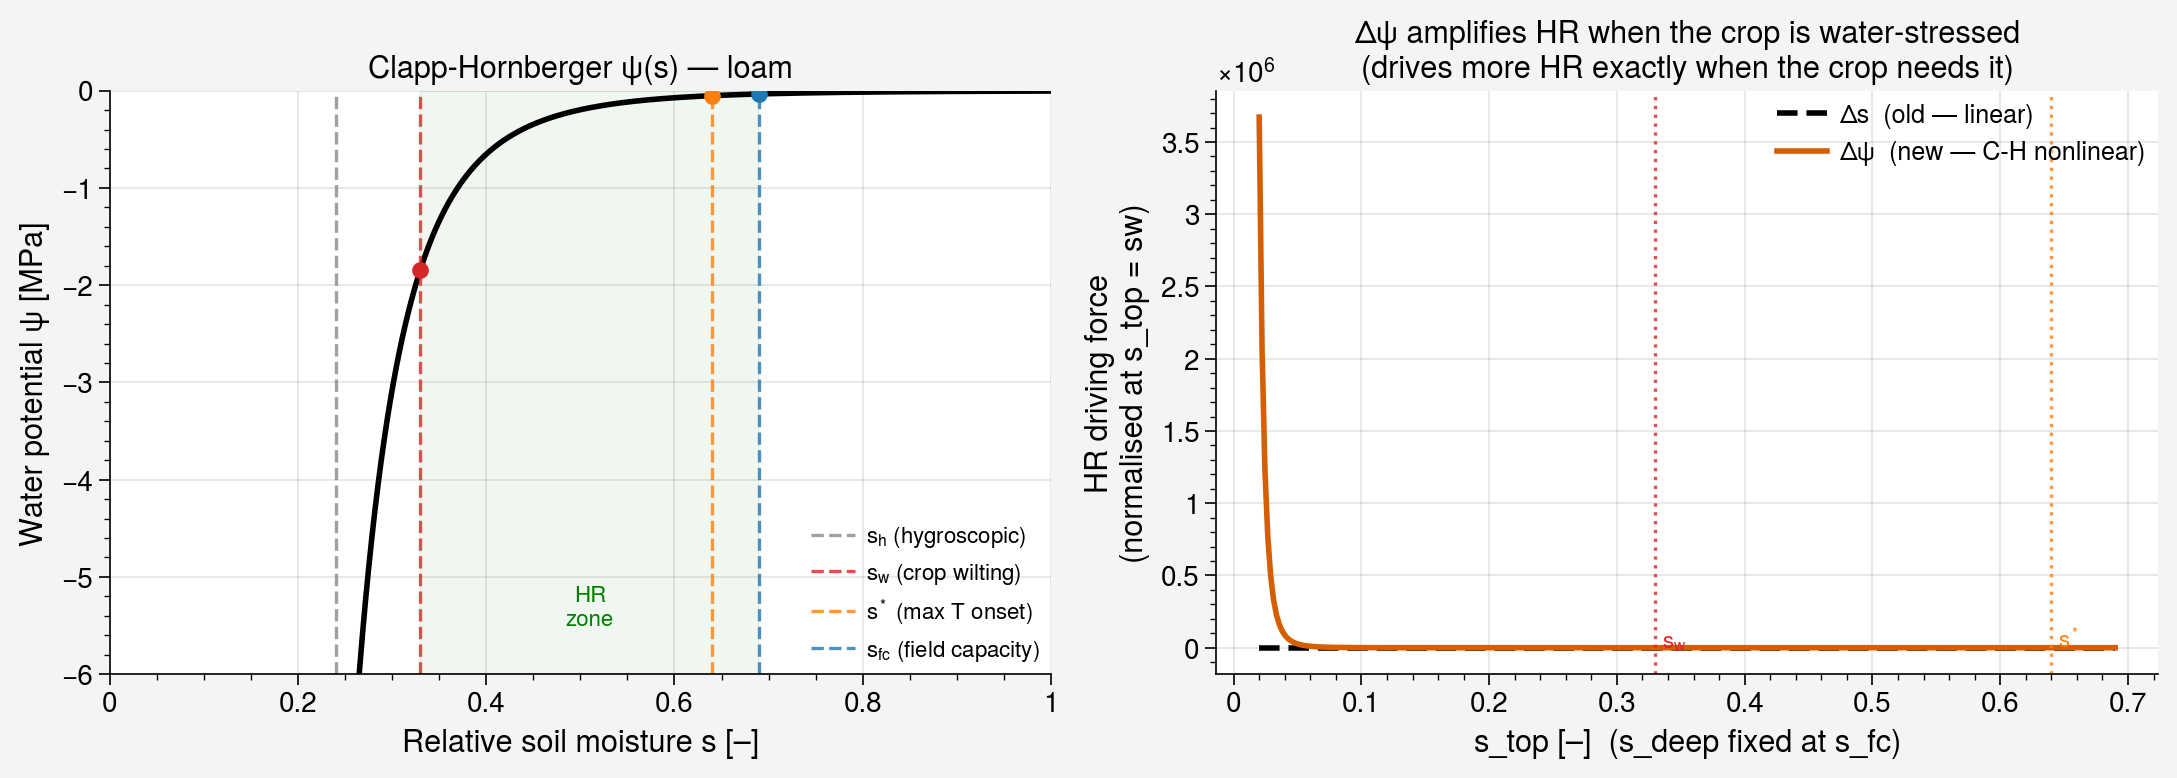

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Left: ψ(s) curve ──────────────────────────────────────────────────────────
ax = axes[0]
s_arr = np.linspace(0.02, 1.0, 600)
psi_arr = soil.Psi_S_MPa * s_arr ** (-soil.b)

ax.plot(s_arr, psi_arr, 'k-', lw=2)
ax.set_xlim(0, 1)
ax.set_ylim(-6, 0)
ax.set_xlabel('Relative soil moisture s [–]')
ax.set_ylabel('Water potential ψ [MPa]')
ax.set_title('Clapp-Hornberger ψ(s) — loam')
despine(ax)

thresholds = [
    (soil.sh,      '$s_h$',   '#888888', 'hygroscopic'),
    (crop.sw,      '$s_w$',   '#d62728', 'crop wilting'),
    (crop.s_star,  '$s^*$',   '#ff7f0e', 'max T onset'),
    (soil.sfc,     '$s_{fc}$','#1f77b4', 'field capacity'),
]
for s_val, label, color, desc in thresholds:
    s_clamped = max(s_val, 0.02)
    psi_val = soil.Psi_S_MPa * s_clamped ** (-soil.b)
    ax.axvline(s_clamped, color=color, ls='--', lw=1.2, alpha=0.8, label=f'{label} ({desc})')
    ax.plot(s_clamped, psi_val, 'o', color=color, ms=5)
ax.legend(loc='lower right', fontsize=8)

# shade the HR-active zone (s_top in [sw, sfc])
ax.axvspan(crop.sw, soil.sfc, alpha=0.06, color='green')
ax.text((crop.sw + soil.sfc)/2, -5.5, 'HR\nzone', ha='center', fontsize=8, color='green')

# ── Right: HR driving force comparison ────────────────────────────────────────
ax = axes[1]
s_deep_fixed = soil.sfc                        # deep layer at field capacity
s_top_arr = np.linspace(0.02, soil.sfc, 300)   # top layer ranges from very dry to sfc

# Old: Δs driver (linear)
delta_s = np.maximum(s_deep_fixed - s_top_arr, 0)

# New: Δψ driver (Clapp-Hornberger)
psi_deep = soil.Psi_S_MPa * s_deep_fixed ** (-soil.b)
psi_top_arr = soil.Psi_S_MPa * s_top_arr ** (-soil.b)
delta_psi = np.maximum(psi_deep - psi_top_arr, 0)

# Normalise both to their value at s_top = sw for comparison
idx_sw = np.argmin(np.abs(s_top_arr - crop.sw))
ds_norm   = delta_s   / delta_s[idx_sw]
dpsi_norm = delta_psi / delta_psi[idx_sw]

ax.plot(s_top_arr, ds_norm,   'k--', lw=2, label='Δs  (old — linear)')
ax.plot(s_top_arr, dpsi_norm, 'C1-', lw=2, label='Δψ  (new — C-H nonlinear)')
ax.axvline(crop.sw,  color='#d62728', ls=':', lw=1.2, alpha=0.8)
ax.axvline(crop.s_star, color='#ff7f0e', ls=':', lw=1.2, alpha=0.8)
ax.text(crop.sw + 0.005,  0.1, '$s_w$',  color='#d62728', fontsize=8)
ax.text(crop.s_star + 0.005, 0.1, '$s^*$', color='#ff7f0e', fontsize=8)
ax.set_xlabel('s_top [–]  (s_deep fixed at s_fc)')
ax.set_ylabel('HR driving force\n(normalised at s_top = sw)')
ax.set_title('Δψ amplifies HR when the crop is water-stressed\n(drives more HR exactly when the crop needs it)')
ax.legend()
despine(ax)

plt.tight_layout()
plt.savefig('../output/gutcheck_1_psi_hr.png')
plt.show()

## Plot 2 — Water balance closure (Fixes 2, 3, 5)

For every timestep in every season: `R − I − Q − T_crop − T_tree − E − L` must equal `dsdt`.
Checks that interception (Fix 5), Laio percolation (Fix 3), and deep drainage (Fix 2) don't leak water.

/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 8321 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 8320 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 8321 missing from current font.
  font.set_text(s, 0, flags=flags)
/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 8320 missing from current font.
  font.set_text(s, 0, flags=flags)


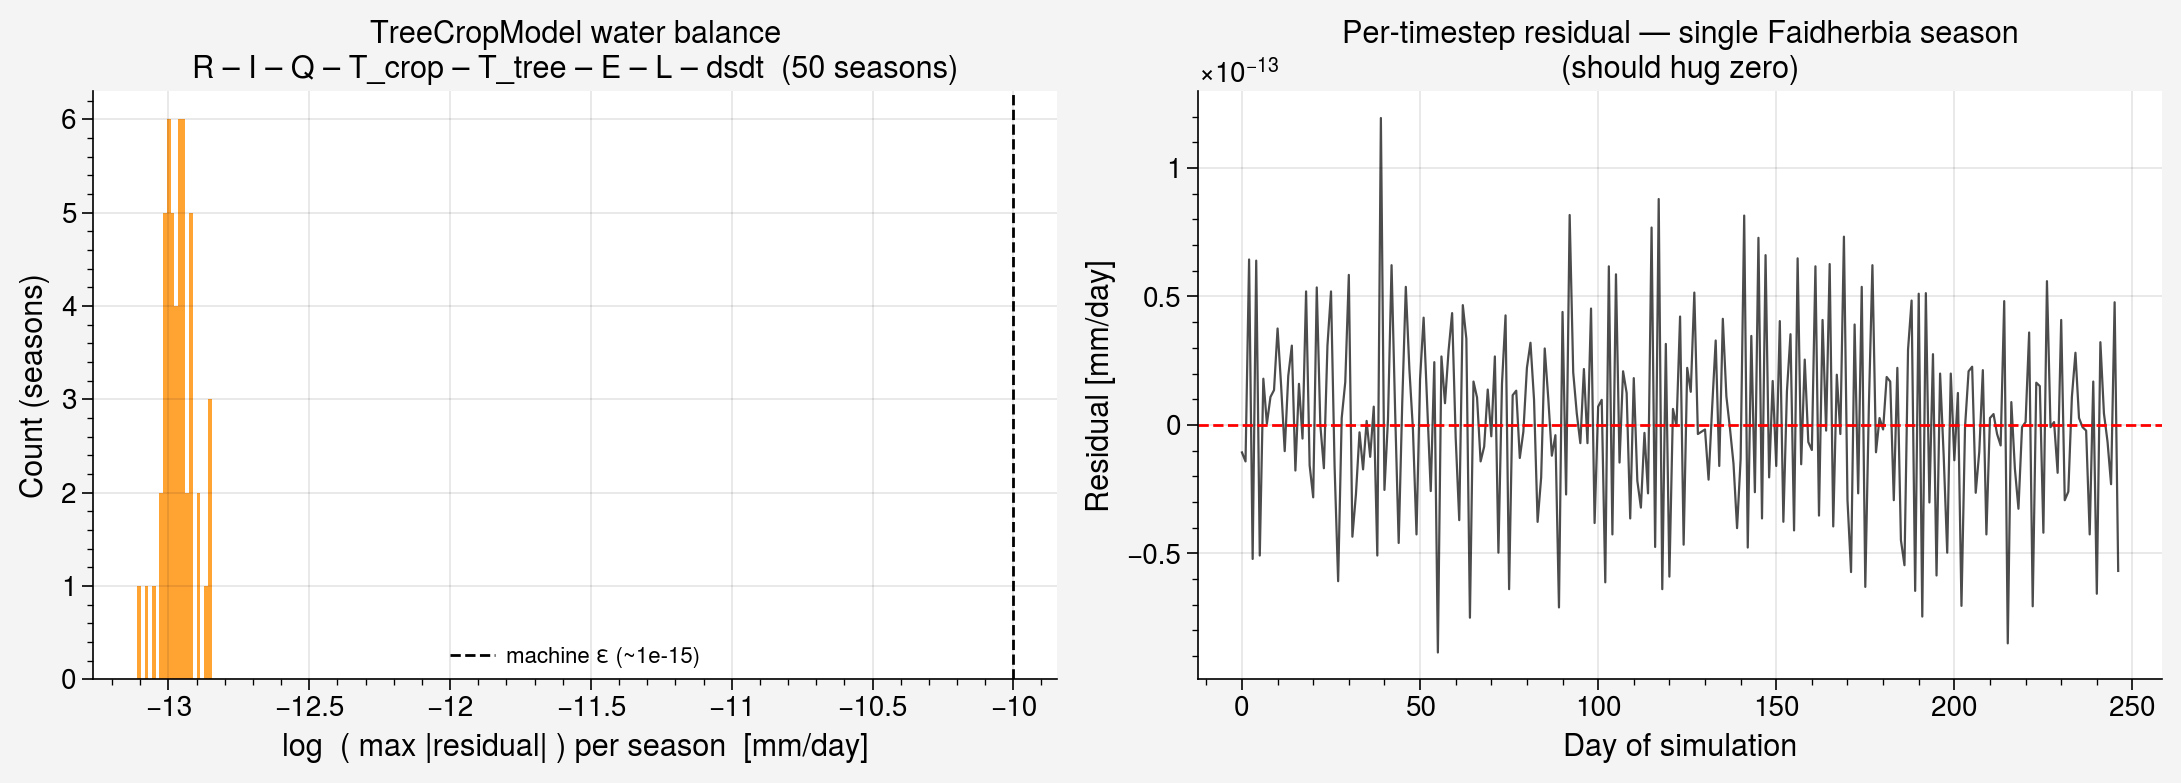

TreeCropModel — max residual across 50 seasons: 1.42e-13 mm/day
Monoculture   — timesteps with implied Q < 0:    0  (should be 0)


In [4]:
N = 50
errors_tree = []
implied_Q_negative_count = 0  # should be 0 for monoculture (Q >= 0 always)

for seed in range(N):
    np.random.seed(seed)
    cli = Climate()

    # Monoculture: CropModel doesn't output Q.
    # Implied Q = R - I - T - E - L - dsdt. Check it's always >= 0.
    s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=180)
    df_m = CropModel(soil=s_, climate=cli, crop=c_).run(do_output=True)
    implied_Q = df_m['R'] - df_m['I'] - df_m['T'] - df_m['E'] - df_m['L'] - df_m['dsdt']
    implied_Q_negative_count += (implied_Q < -1e-10).sum()

    # Faidherbia TreeCropModel: Q IS in output — check full balance
    s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=180)
    tr_ = Tree(Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
               kc=1.0, canopy_cover=0.2, leaf_fraction=0.0, soil=s_)
    df_t = TreeCropModel(soil=s_, climate=cli, crop=c_, tree=tr_).run(do_output=True)
    resid_t = (df_t['R'] - df_t['I'] - df_t['Q'] - df_t['T_crop'] - df_t['T_tree']
               - df_t['E'] - df_t['L'] - df_t['dsdt'])
    errors_tree.append(resid_t.abs().max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: histogram of max residual per season (TreeCropModel)
ax = axes[0]
ax.hist(np.log10(np.array(errors_tree) + 1e-16), bins=20, color='darkorange', alpha=0.8)
ax.set_xlabel('log₁₀( max |residual| ) per season  [mm/day]')
ax.set_ylabel('Count (seasons)')
ax.set_title(f'TreeCropModel water balance\nR – I – Q – T_crop – T_tree – E – L – dsdt  ({N} seasons)')
ax.axvline(-10, color='k', ls='--', lw=1, label='machine ε (~1e-15)')
ax.legend(fontsize=8)
despine(ax)

# Right: time-series residual for one Faidherbia season
np.random.seed(7)
s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=180)
tr_ = Tree(Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
           kc=1.0, canopy_cover=0.2, leaf_fraction=0.0, soil=s_)
df_check = TreeCropModel(soil=s_, climate=Climate(), crop=c_, tree=tr_).run(do_output=True)
resid_ts = (df_check['R'] - df_check['I'] - df_check['Q'] - df_check['T_crop']
            - df_check['T_tree'] - df_check['E'] - df_check['L'] - df_check['dsdt'])

ax = axes[1]
ax.plot(resid_ts.values, 'k-', lw=0.8, alpha=0.7)
ax.axhline(0, color='red', lw=1, ls='--')
ax.set_xlabel('Day of simulation')
ax.set_ylabel('Residual [mm/day]')
ax.set_title('Per-timestep residual — single Faidherbia season\n(should hug zero)')
despine(ax)

plt.tight_layout()
plt.savefig('../output/gutcheck_2_water_balance.png')
plt.show()

print(f'TreeCropModel — max residual across {N} seasons: {max(errors_tree):.2e} mm/day')
print(f'Monoculture   — timesteps with implied Q < 0:    {implied_Q_negative_count}  (should be 0)')

## Plot 3 — Faidherbia single-season trace (Fixes 1, 2, 3)

Four panels for one season:
- **s_top / s_deep**: percolation (Fix 3) fills the deep layer after rain; deep drains between events (Fix 2)
- **HR flux**: nonzero only when `s_deep > s_top`; larger when the gradient is steep (Fix 1)
- **T_tree**: zero throughout crop season (reverse phenology working)
- **Fluxes**: T_crop, E, rain

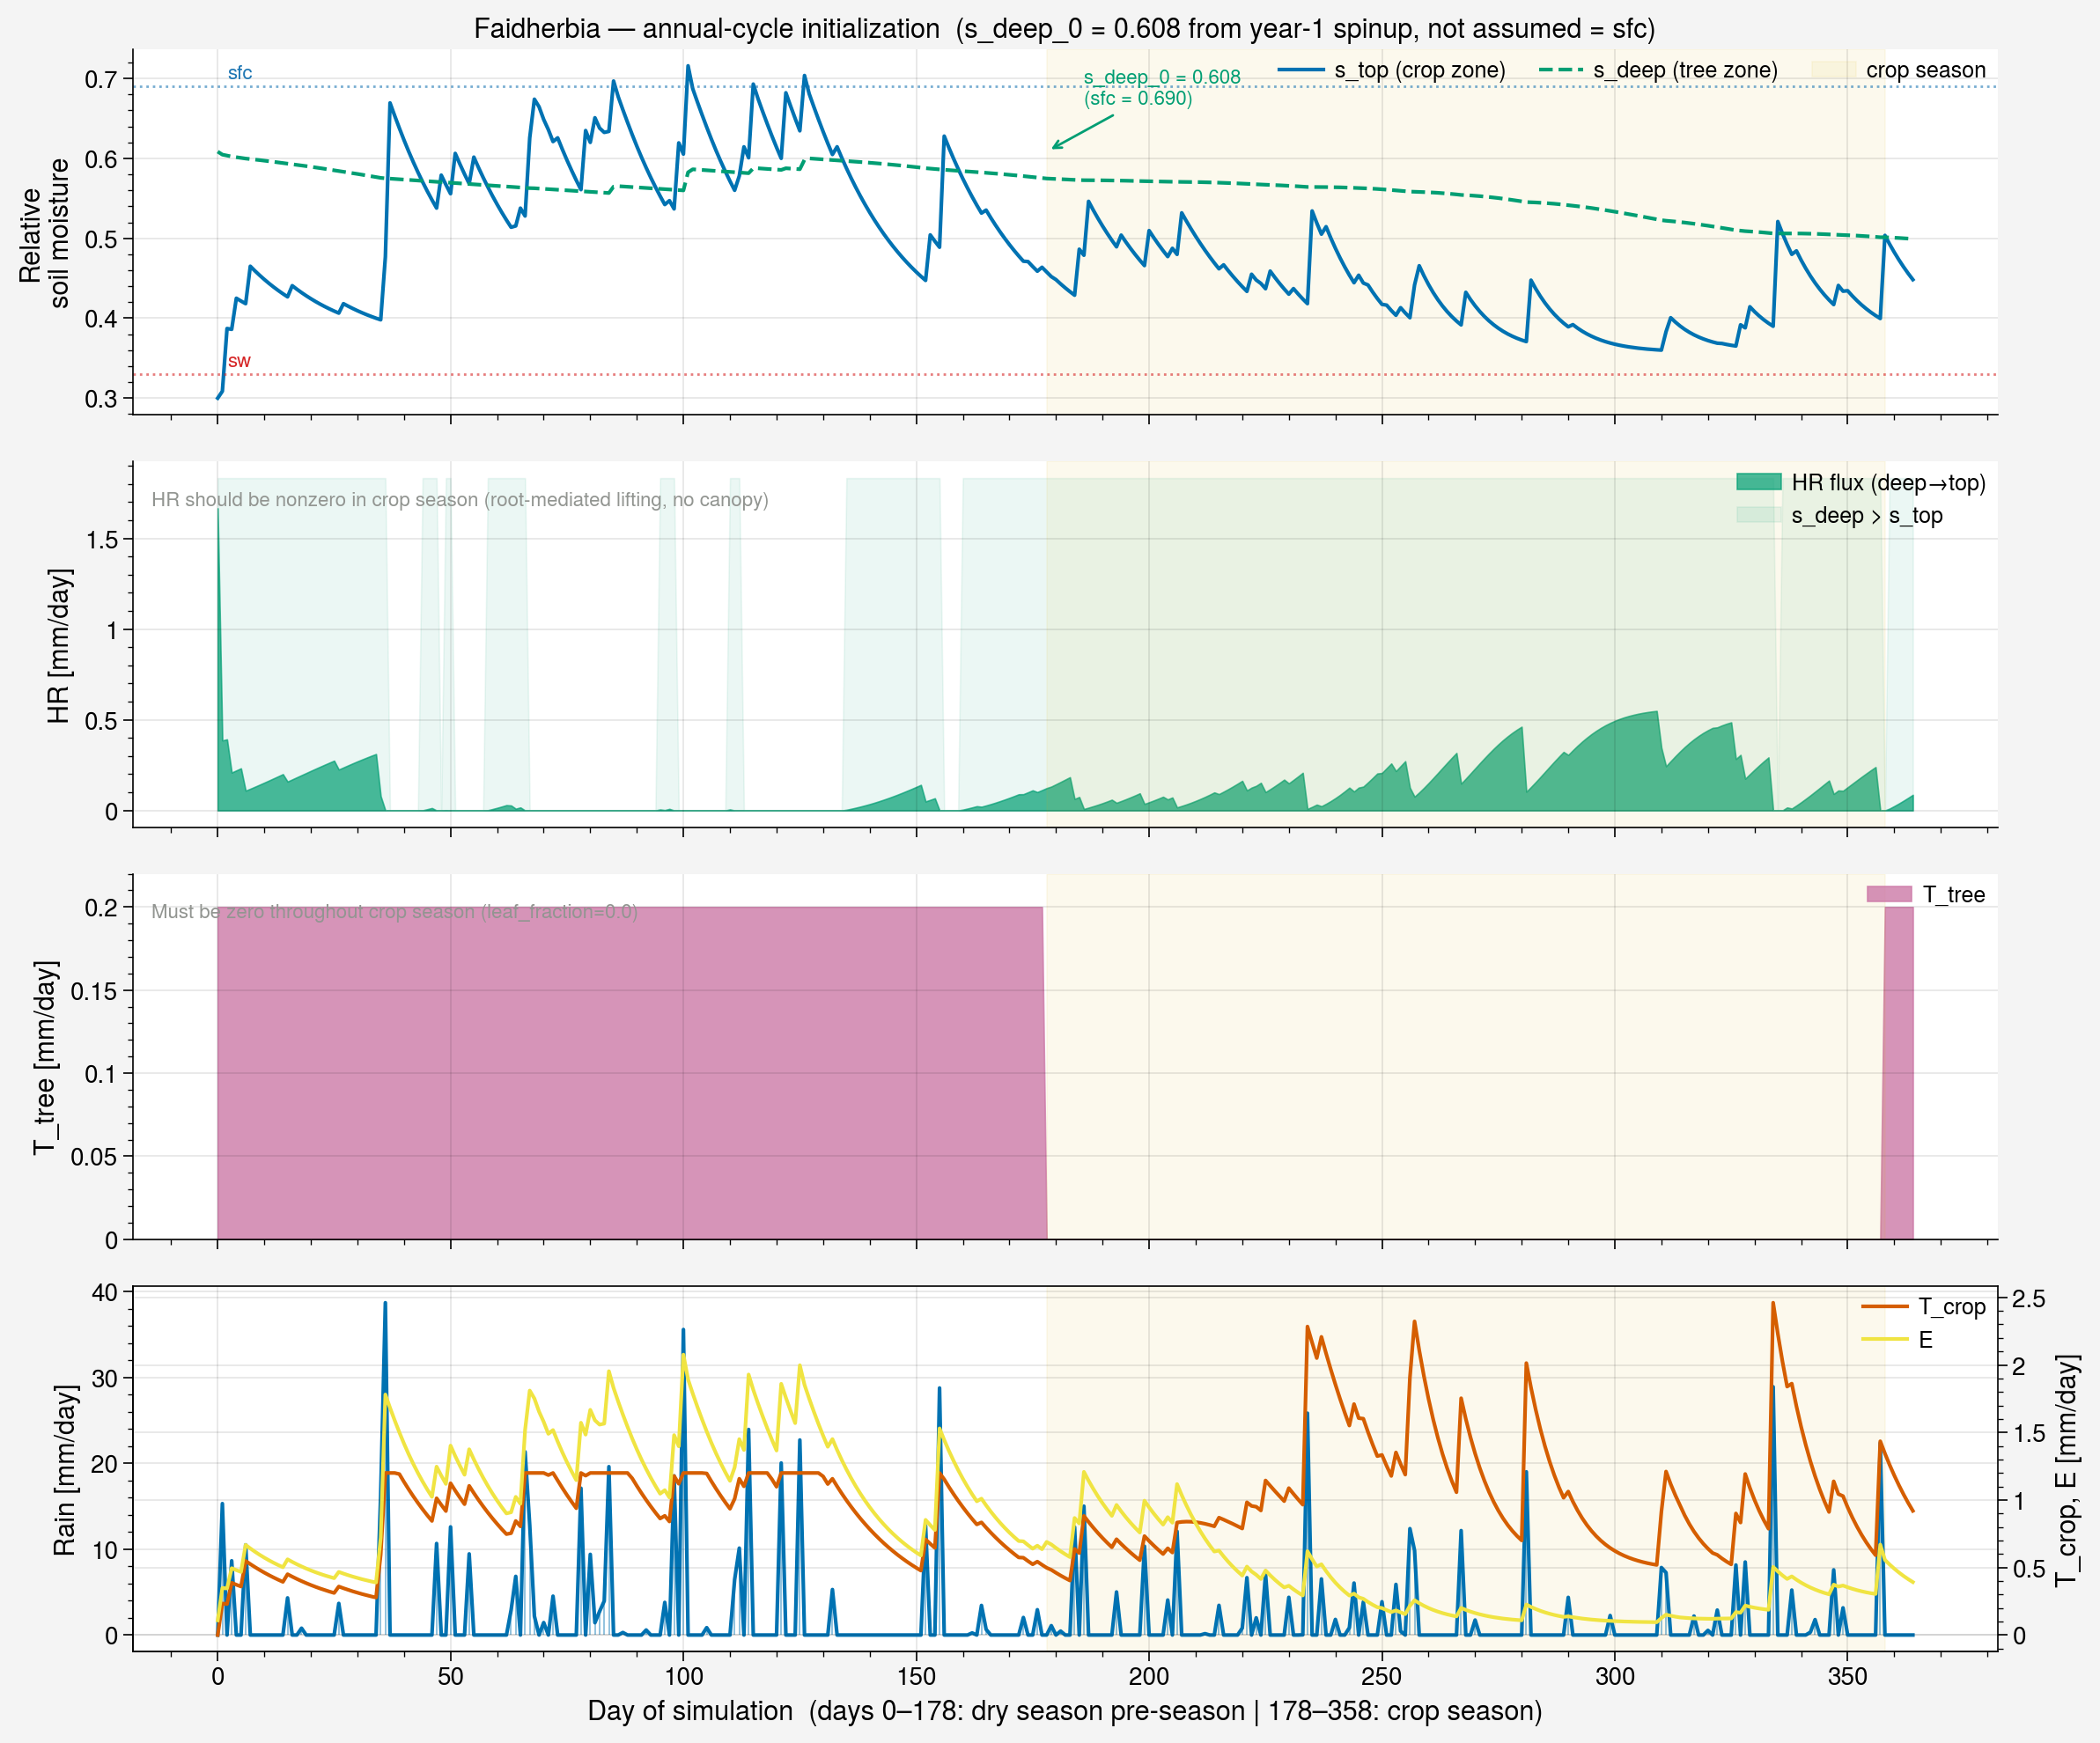

s_deep at planting (endogenous): 0.608  (sfc = 0.690)
Max T_tree during crop season:   0.0000 mm/day  (should be 0.0)
Mean HR during crop season:      0.2026 mm/day  (should be > 0)
Max s_deep: 0.608   Min s_deep: 0.499
Deep drains below sfc: True  (should be True)


In [5]:
lgp = 180; t_after = 7; t_before_full = 365 - lgp - t_after  # 178

# ── Year 1 spinup: endogenous s_deep at planting ──────────────────────────────
np.random.seed(42)
s1 = Soil(texture='loam'); c1 = Crop(soil=s1, lgp=lgp)
tr1 = Tree(Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
           kc=1.0, canopy_cover=0.2, leaf_fraction=0.0, soil=s1)
m1 = TreeCropModel(soil=s1, climate=Climate(), crop=c1, tree=tr1)
m1.run(t_before=t_before_full, t_after=t_after)
s_deep_init = m1.s_deep[-1]

# ── Year 2: paired season with endogenous s_deep_0 ───────────────────────────
np.random.seed(43)
s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=lgp)
tr_ = Tree(Zr=1500, T_MAX=1.0, sw_MPa=-2.0, s_star_MPa=-0.1,
           kc=1.0, canopy_cover=0.2, leaf_fraction=0.0, soil=s_)
m_ = TreeCropModel(soil=s_, climate=Climate(), crop=c_, tree=tr_)
df = m_.run(do_output=True, t_before=t_before_full, t_after=t_after,
            s_deep_0=s_deep_init)

t = np.arange(len(df))
planting = t_before_full
harvest  = planting + lgp

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# Panel 1: soil moisture both layers
ax = axes[0]
ax.plot(t, df['s_top'].values,  'C0-',  lw=1.5, label='s_top (crop zone)')
ax.plot(t, df['s_deep'].values, 'C2--', lw=1.5, label='s_deep (tree zone)')
ax.axhline(s_.sfc,  color='#1f77b4', ls=':', lw=1, alpha=0.6)
ax.axhline(c_.sw,   color='#d62728', ls=':', lw=1, alpha=0.6)
ax.text(2, s_.sfc + 0.01, 'sfc', fontsize=8, color='#1f77b4')
ax.text(2, c_.sw  + 0.01, 'sw',  fontsize=8, color='#d62728')
ax.axvspan(planting, harvest, alpha=0.07, color='gold', label='crop season')
# Annotate endogenous s_deep at planting
ax.annotate(f's_deep_0 = {s_deep_init:.3f}\n(sfc = {s_.sfc:.3f})',
            xy=(planting, s_deep_init), xytext=(planting + 8, s_deep_init + 0.06),
            fontsize=8, color='C2',
            arrowprops=dict(arrowstyle='->', color='C2', lw=1))
ax.set_ylabel('Relative\nsoil moisture')
ax.legend(loc='upper right', ncol=3)
ax.set_title('Faidherbia — annual-cycle initialization  '
             f'(s_deep_0 = {s_deep_init:.3f} from year-1 spinup, not assumed = sfc)',
             fontsize=11)
despine(ax)

# Panel 2: HR flux
ax = axes[1]
ax.fill_between(t, 0, df['HR'].values, color='C2', alpha=0.7, label='HR flux (deep→top)')
cond = (df['s_deep'].values > df['s_top'].values)
ax.fill_between(t, 0, df['HR'].values.max() * cond * 1.1,
                color='C2', alpha=0.08, label='s_deep > s_top')
ax.axvspan(planting, harvest, alpha=0.07, color='gold')
ax.set_ylabel('HR [mm/day]')
ax.legend(loc='upper right')
ax.text(0.01, 0.88, 'HR should be nonzero in crop season (root-mediated lifting, no canopy)',
        transform=ax.transAxes, fontsize=8, color='gray')
despine(ax)

# Panel 3: T_tree (should be 0 during crop season for Faidherbia)
ax = axes[2]
ax.fill_between(t, 0, df['T_tree'].values, color='C3', alpha=0.8, label='T_tree')
ax.axvspan(planting, harvest, alpha=0.07, color='gold')
ax.set_ylim(0, df['T_tree'].values.max() * 1.1)
ax.set_ylabel('T_tree [mm/day]')
ax.legend(loc='upper right')
ax.text(0.01, 0.88, 'Must be zero throughout crop season (leaf_fraction=0.0)',
        transform=ax.transAxes, fontsize=8, color='gray')
despine(ax)

# Panel 4: crop fluxes + rain
ax = axes[3]
markerline, stemlines, baseline = ax.stem(
    t, df['R'].values, linefmt='C0-', markerfmt='', basefmt=' ')
plt.setp(stemlines, lw=0.6, alpha=0.5)
ax2 = ax.twinx()
ax2.plot(t, df['T_crop'].values, 'C1-', lw=1.5, label='T_crop')
ax2.plot(t, df['E'].values,      'C4-', lw=1.5, label='E')
ax2.set_ylabel('T_crop, E [mm/day]')
ax.set_ylabel('Rain [mm/day]')
ax.axvspan(planting, harvest, alpha=0.07, color='gold')
ax.set_xlabel('Day of simulation  (days 0–178: dry season pre-season | 178–358: crop season)')
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines2, labels2, loc='upper right')
despine(ax)

plt.tight_layout()
plt.savefig('../output/gutcheck_3_faidherbia_trace.png')
plt.show()

# Numeric checks
in_season = (df['dos'].values > 0) & (df['dos'].values <= lgp)
print(f's_deep at planting (endogenous): {s_deep_init:.3f}  (sfc = {s_.sfc:.3f})')
print(f'Max T_tree during crop season:   {df["T_tree"].values[in_season].max():.4f} mm/day  (should be 0.0)')
print(f'Mean HR during crop season:      {df["HR"].values[in_season].mean():.4f} mm/day  (should be > 0)')
print(f'Max s_deep: {df["s_deep"].values.max():.3f}   Min s_deep: {df["s_deep"].values.min():.3f}')
print(f'Deep drains below sfc: {(df["s_deep"].values < s_.sfc).any()}  (should be True)')

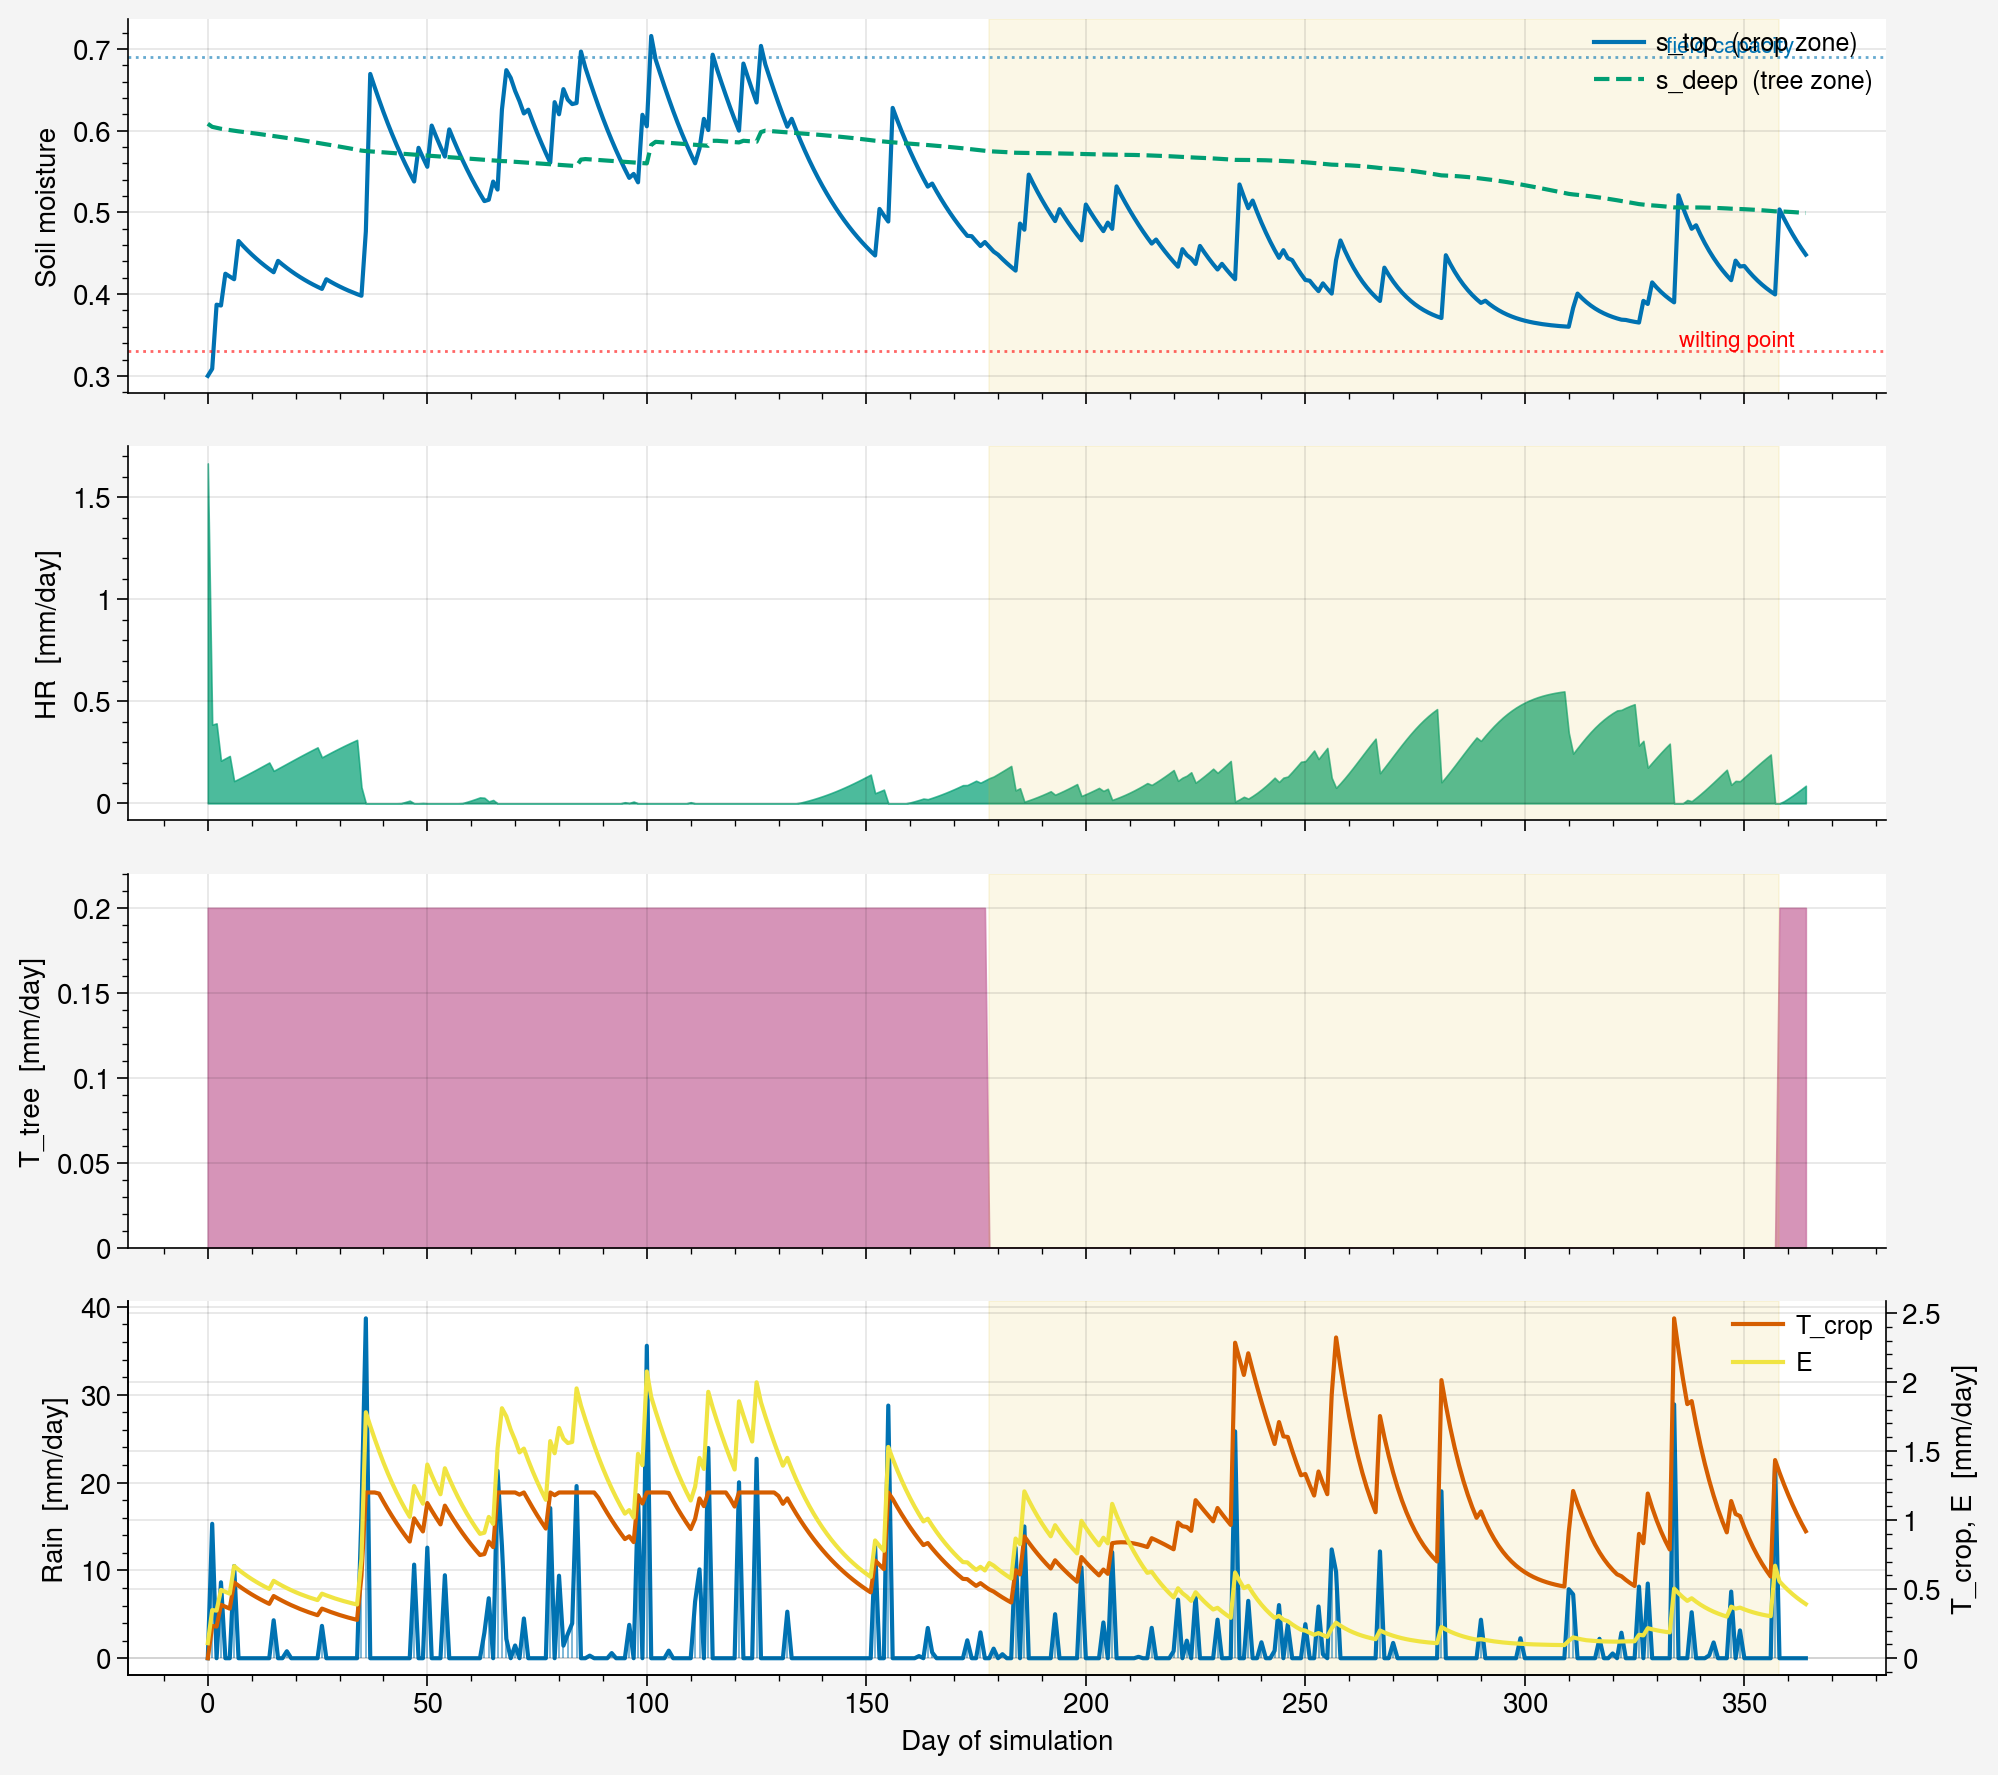

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

# Panel 1: soil moisture
ax = axes[0]
ax.plot(t, df['s_top'].values,  color='C0', lw=1.5, label='s_top  (crop zone)')
ax.plot(t, df['s_deep'].values, color='C2', lw=1.5, ls='--', label='s_deep  (tree zone)')
ax.axhline(s_.sfc, color='C0', ls=':', lw=1, alpha=0.6)
ax.axhline(c_.sw,  color='red', ls=':', lw=1, alpha=0.6)
ax.text(len(t)*0.99, s_.sfc, 'field capacity', fontsize=8, color='C0', ha='right', va='bottom')
ax.text(len(t)*0.99, c_.sw,  'wilting point',  fontsize=8, color='red', ha='right', va='bottom')
ax.axvspan(planting, harvest, alpha=0.10, color='gold')
ax.set_ylabel('Soil moisture', fontsize=10)
ax.legend(fontsize=9, frameon=False)
despine(ax)

# Panel 2: HR flux
ax = axes[1]
ax.fill_between(t, 0, df['HR'].values, color='C2', alpha=0.7)
ax.axvspan(planting, harvest, alpha=0.10, color='gold')
ax.set_ylabel('HR  [mm/day]', fontsize=10)
despine(ax)

# Panel 3: T_tree
ax = axes[2]
ax.fill_between(t, 0, df['T_tree'].values, color='C3', alpha=0.8)
ax.set_ylim(0, df['T_tree'].values.max() * 1.1)
ax.axvspan(planting, harvest, alpha=0.10, color='gold')
ax.set_ylabel('T_tree  [mm/day]', fontsize=10)
despine(ax)

# Panel 4: rain + crop fluxes
ax = axes[3]
markerline, stemlines, baseline = ax.stem(
    t, df['R'].values, linefmt='C0-', markerfmt='', basefmt=' ')
plt.setp(stemlines, lw=0.7, alpha=0.5)
ax2 = ax.twinx()
ax2.plot(t, df['T_crop'].values, color='C1', lw=1.5, label='T_crop')
ax2.plot(t, df['E'].values,      color='C4', lw=1.5, label='E')
ax2.spines['top'].set_visible(False)
ax2.set_ylabel('T_crop, E  [mm/day]', fontsize=10)
ax.axvspan(planting, harvest, alpha=0.10, color='gold')
ax.set_ylabel('Rain  [mm/day]', fontsize=10)
ax.set_xlabel('Day of simulation', fontsize=10)
ax2.legend(fontsize=9, frameon=False, loc='upper right')
despine(ax)

plt.tight_layout()
plt.savefig('../output/gutcheck_3_faidherbia_trace_simple.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 4 — Shade affects E but not T_crop (Fix 4)

Run the same season twice — `shade_on=True` vs `shade_on=False` — with an evergreen tree.
After Fix 4:
- **E** should be lower with shade (Beer-Lambert suppression)
- **T_crop** should be **≥ shade-off** values — shade keeps soil wetter → indirect benefit

Note: `ΔT_crop` will **not** be zero. It will be positive (or near-zero on unstressed days).
The sign of `ΔT_crop` is what matters: Fix 4 flips the shade effect on T_crop from
**negative** (old code directly suppressed T_crop) to **positive/neutral** (soil moisture pathway only).
A functional spot-check at the bottom confirms sf is not in the T_crop calculation.

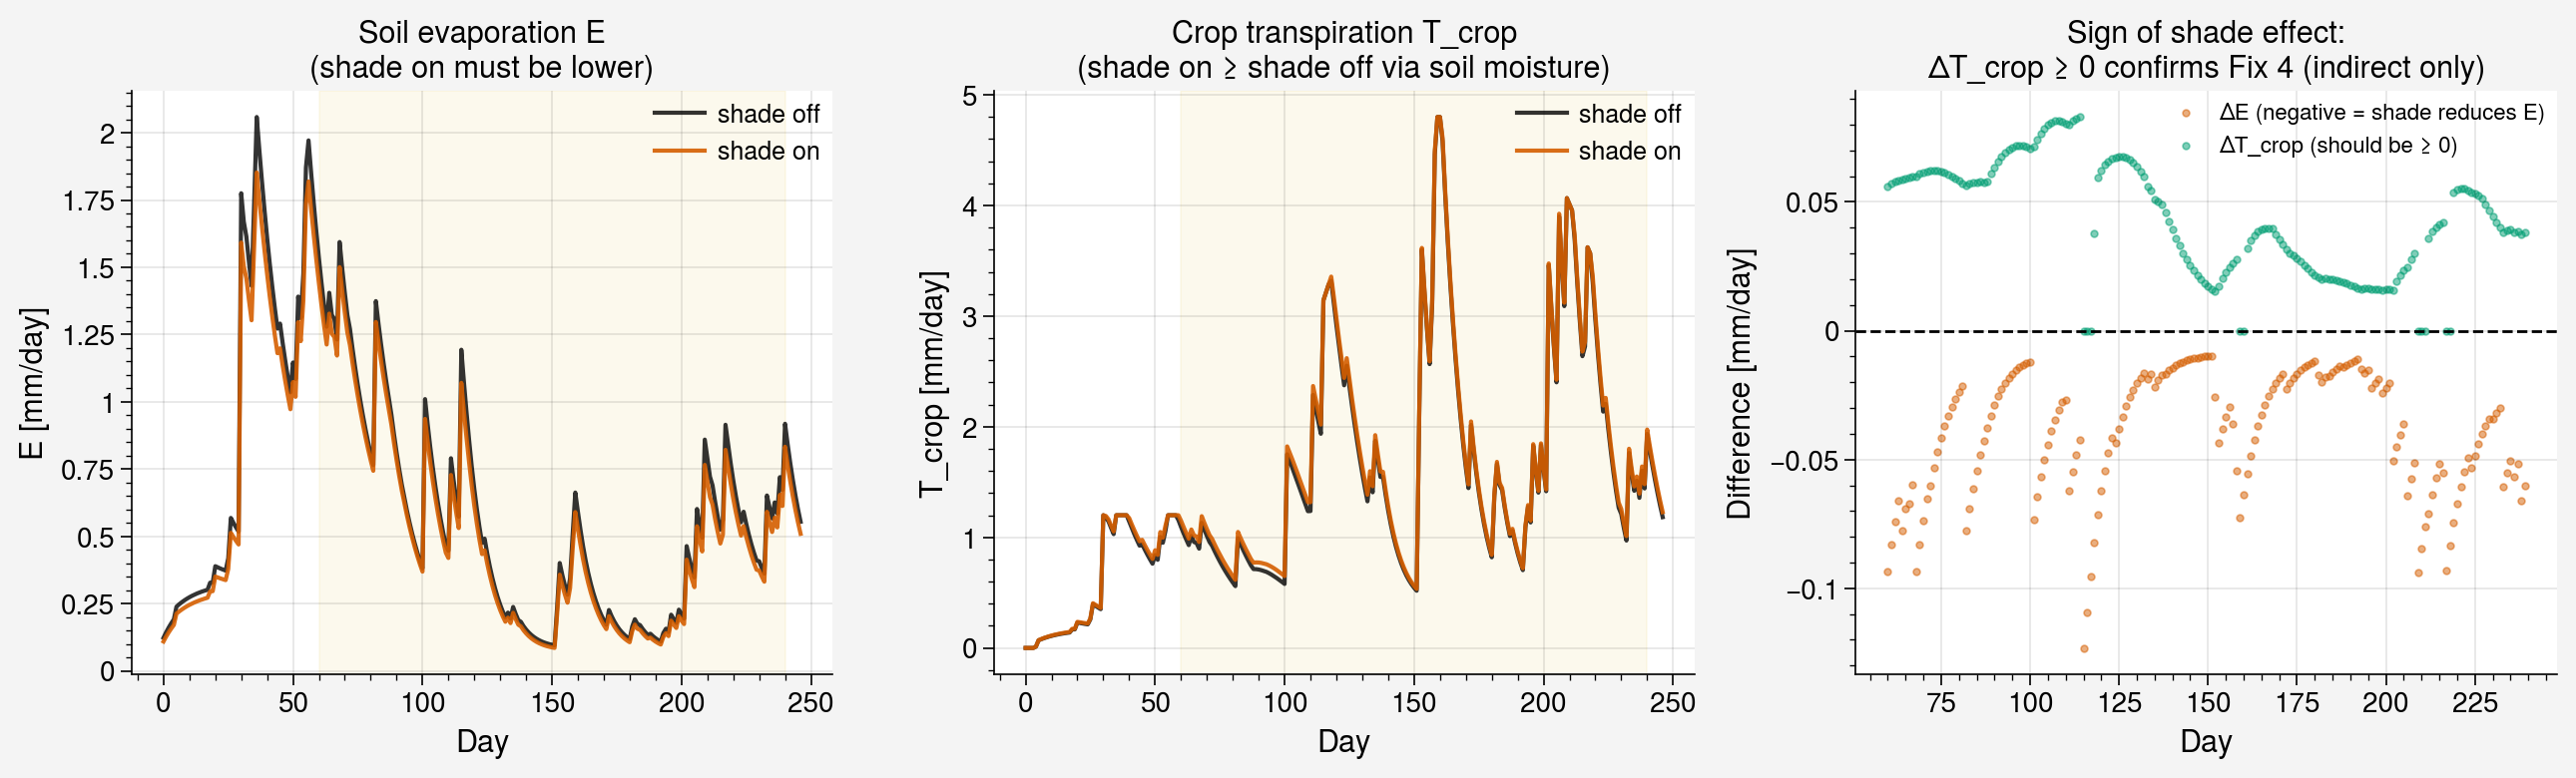

Mean E reduction from shade:      0.0396 mm/day  (should be > 0)
Fraction of days ΔT_crop ≥ 0:    100.00%  (should be near 100% — Fix 4)
Cumulative E:  shade on = 91.2 mm   shade off = 98.4 mm
Cumulative T_crop:  shade on = 323.4 mm   shade off = 315.6 mm

Functional check: crop.calc_T(0.5, LAI=2.0) = 1.7548 mm/day
shade_factor = 0.8869   — T_crop does NOT use this  (Fix 4 confirmed at function level)


In [7]:
np.random.seed(42)
cli_ = Climate()

def run_shade(shade_on):
    s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=180)
    tr_ = Tree(Zr=1500, T_MAX=4.0, sw_MPa=-2.0, s_star_MPa=-0.1,
               kc=1.0, canopy_cover=0.2, leaf_fraction=1.0, soil=s_)
    m_ = TreeCropModel(soil=s_, climate=cli_, crop=c_, tree=tr_)
    return m_.run(do_output=True, shade_on=shade_on)

df_shade_on  = run_shade(True)
df_shade_off = run_shade(False)

in_season = (df_shade_on['dos'].values > 0) & (df_shade_on['dos'].values <= 180)
t = np.arange(len(df_shade_on))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: E comparison (unambiguous — shade must reduce E)
ax = axes[0]
ax.plot(t, df_shade_off['E'].values, 'k-',  lw=1.5, alpha=0.8, label='shade off')
ax.plot(t, df_shade_on['E'].values,  'C1-', lw=1.5, alpha=0.9, label='shade on')
ax.axvspan(60, 60+180, alpha=0.07, color='gold')
ax.set_xlabel('Day'); ax.set_ylabel('E [mm/day]')
ax.set_title('Soil evaporation E\n(shade on must be lower)')
ax.legend()
despine(ax)

# Panel 2: T_crop — should be >= shade-off (indirect soil moisture benefit)
ax = axes[1]
ax.plot(t, df_shade_off['T_crop'].values, 'k-',  lw=1.5, alpha=0.8, label='shade off')
ax.plot(t, df_shade_on['T_crop'].values,  'C1-', lw=1.5, alpha=0.9, label='shade on')
ax.axvspan(60, 60+180, alpha=0.07, color='gold')
ax.set_xlabel('Day'); ax.set_ylabel('T_crop [mm/day]')
ax.set_title('Crop transpiration T_crop\n(shade on ≥ shade off via soil moisture)')
ax.legend()
despine(ax)

# Panel 3: ΔT_crop should be ≥ 0 (positive = shade indirectly helped the crop)
ax = axes[2]
diff_E     = df_shade_on['E'].values      - df_shade_off['E'].values   # < 0 (shade reduces E)
diff_Tcrop = df_shade_on['T_crop'].values - df_shade_off['T_crop'].values  # should be >= 0
ax.scatter(t[in_season], diff_E[in_season],     s=6,  color='C1', alpha=0.5, label='ΔE (negative = shade reduces E)')
ax.scatter(t[in_season], diff_Tcrop[in_season], s=6,  color='C2', alpha=0.5, label='ΔT_crop (should be ≥ 0)')
ax.axhline(0, color='k', lw=1, ls='--')
ax.set_xlabel('Day'); ax.set_ylabel('Difference [mm/day]')
ax.set_title('Sign of shade effect:\nΔT_crop ≥ 0 confirms Fix 4 (indirect only)')
ax.legend(fontsize=8)
despine(ax)

plt.tight_layout()
plt.savefig('../output/gutcheck_4_shade_fix.png')
plt.show()

# Quantitative checks
mean_E_reduction = (-diff_E[in_season]).mean()
frac_positive_Tcrop = (diff_Tcrop[in_season] >= -1e-10).mean()
print(f'Mean E reduction from shade:      {mean_E_reduction:.4f} mm/day  (should be > 0)')
print(f'Fraction of days ΔT_crop ≥ 0:    {frac_positive_Tcrop:.2%}  (should be near 100% — Fix 4)')
print(f'Cumulative E:  shade on = {df_shade_on["E"][in_season].sum():.1f} mm   shade off = {df_shade_off["E"][in_season].sum():.1f} mm')
print(f'Cumulative T_crop:  shade on = {df_shade_on["T_crop"][in_season].sum():.1f} mm   shade off = {df_shade_off["T_crop"][in_season].sum():.1f} mm')

# Functional spot-check: at a fixed s, crop.calc_T ignores shade entirely
s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=180)
s_test, LAI_test = 0.5, 2.0
T_direct = c_.calc_T(s_test, LAI=LAI_test)
sf_val   = shade_factor(LAI_test * 0.2)
print(f'\nFunctional check: crop.calc_T({s_test}, LAI={LAI_test}) = {T_direct:.4f} mm/day')
print(f'shade_factor = {sf_val:.4f}   — T_crop does NOT use this  (Fix 4 confirmed at function level)')

## Plot 5 — Monoculture equivalence

`TreeCropModel` with a ghost tree (`T_MAX=0`, `canopy_cover=0`, `deep_roots=False`, `hr_on=False`, `shade_on=False`)
should reproduce the published `CropModel` exactly — same rainfall, same soil, same crop.

**What this checks:** the two-layer bucket collapses to the single-bucket when the tree has no effect.
Any residual above machine precision reveals a structural difference between the two models.

Note: a small order-of-operations difference is expected — CropModel computes T, E, L all from the same
intermediate s (post-rain), while TreeCropModel drains first then computes T/E. This causes tiny (~0.001)
stress residuals on heavy-rain days. That is acceptable; what we are ruling out is a systematic bias.

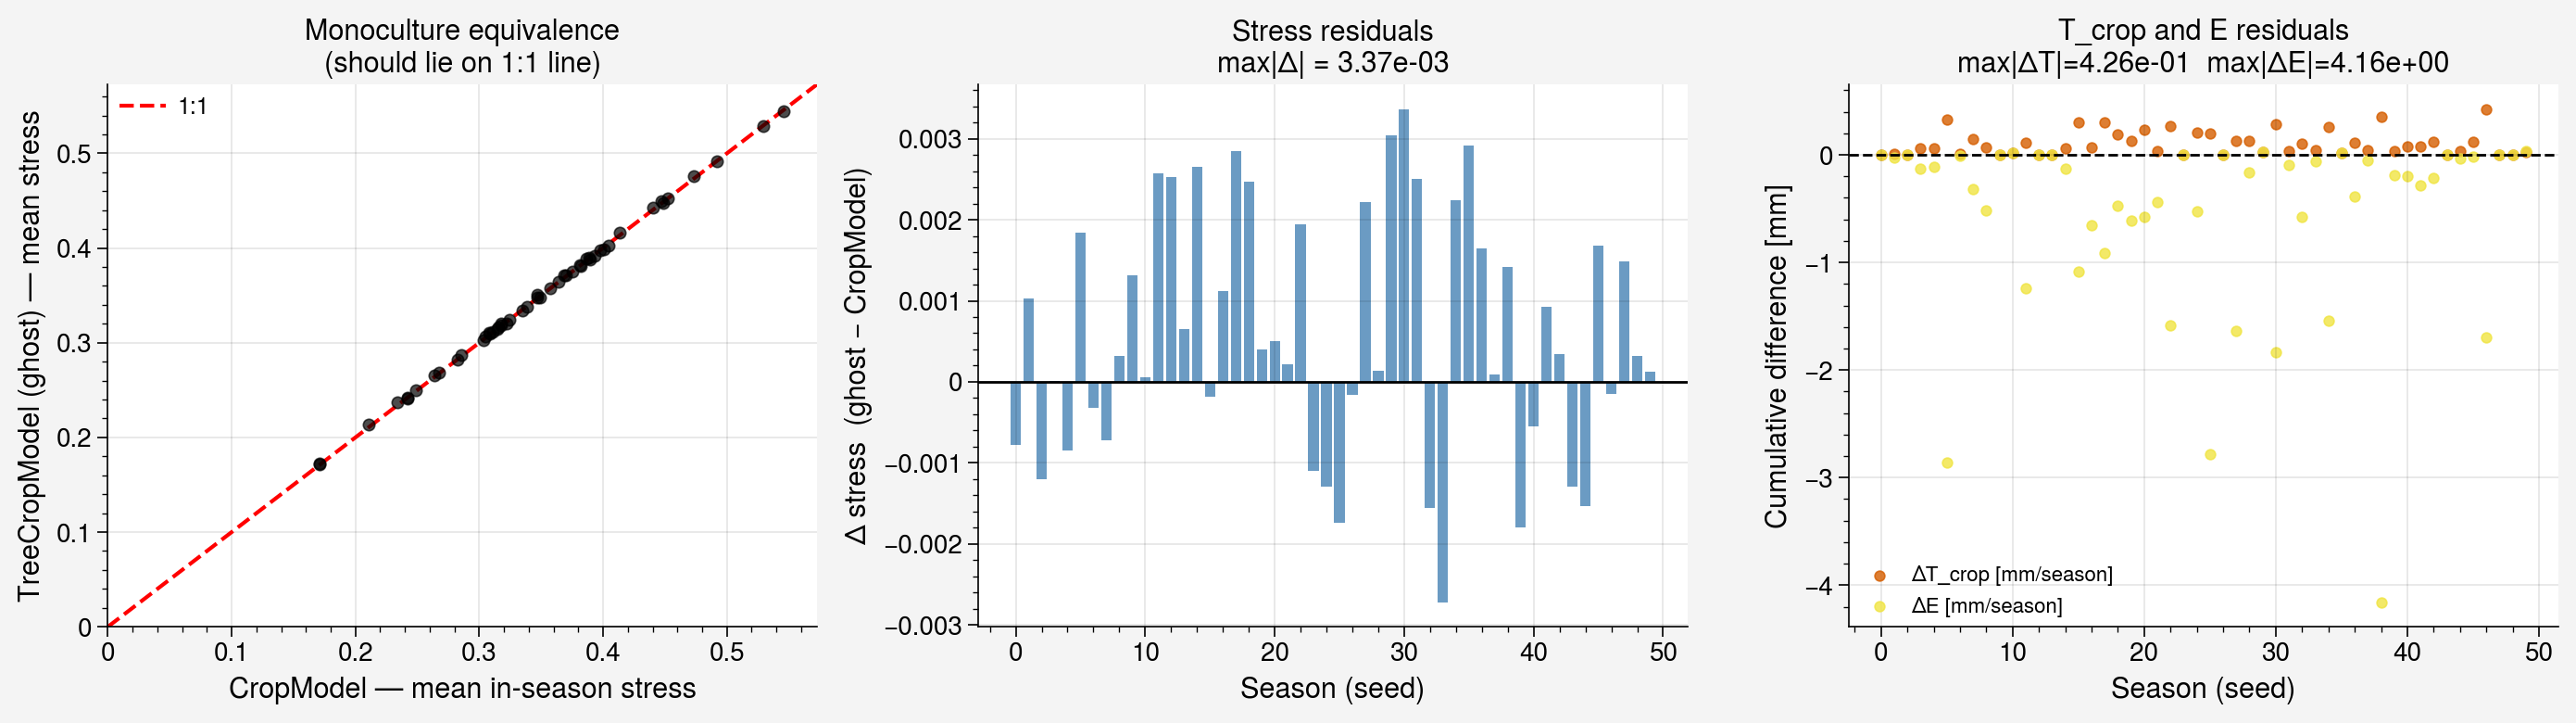

Stress:  max|Δ| = 3.37e-03   mean|Δ| = 1.30e-03
T_crop:  max|Δ| = 4.26e-01 mm/season
E:       max|Δ| = 4.16e+00 mm/season
Verdict: PASS — effectively equivalent


In [8]:
N = 50
mono_stress, ghost_stress = [], []
mono_cum_T, ghost_cum_T   = [], []
mono_cum_E, ghost_cum_E   = [], []

for seed in range(N):
    np.random.seed(seed)
    cli = Climate()

    # 1. Published CropModel
    s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=180)
    df_m = CropModel(soil=s_, climate=cli, crop=c_).run(do_output=True)
    in_s = (df_m['dos'].values > 0) & (df_m['dos'].values <= 180)
    mono_stress.append(df_m['stress'].values[in_s].mean())
    mono_cum_T.append(df_m['T'].values[in_s].sum())
    mono_cum_E.append(df_m['E'].values[in_s].sum())

    # 2. TreeCropModel with ghost tree (zero effect on crop)
    s_ = Soil(texture='loam'); c_ = Crop(soil=s_, lgp=180)
    ghost = Tree(Zr=1500, T_MAX=0.0, kc=1.0, canopy_cover=0.0,
                 leaf_fraction=1.0, soil=s_)
    df_g = TreeCropModel(soil=s_, climate=cli, crop=c_, tree=ghost).run(
        do_output=True, hr_on=False, shade_on=False, deep_roots=False)
    in_s = (df_g['dos'].values > 0) & (df_g['dos'].values <= 180)
    ghost_stress.append(df_g['stress'].values[in_s].mean())
    ghost_cum_T.append(df_g['T_crop'].values[in_s].sum())
    ghost_cum_E.append(df_g['E'].values[in_s].sum())

mono_stress  = np.array(mono_stress);  ghost_stress  = np.array(ghost_stress)
mono_cum_T   = np.array(mono_cum_T);   ghost_cum_T   = np.array(ghost_cum_T)
mono_cum_E   = np.array(mono_cum_E);   ghost_cum_E   = np.array(ghost_cum_E)
d_stress     = ghost_stress - mono_stress
d_T          = ghost_cum_T  - mono_cum_T
d_E          = ghost_cum_E  - mono_cum_E

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: stress scatter — should fall on 1:1 line
ax = axes[0]
lim = [0, max(mono_stress.max(), ghost_stress.max()) * 1.05]
ax.scatter(mono_stress, ghost_stress, s=20, color='k', alpha=0.7, zorder=3)
ax.plot(lim, lim, 'r--', lw=1.5, label='1:1')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('CropModel — mean in-season stress')
ax.set_ylabel('TreeCropModel (ghost) — mean stress')
ax.set_title('Monoculture equivalence\n(should lie on 1:1 line)')
ax.legend()
despine(ax)

# Panel 2: stress residuals by season
ax = axes[1]
ax.bar(range(N), d_stress, color='steelblue', alpha=0.8)
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('Season (seed)')
ax.set_ylabel('Δ stress  (ghost − CropModel)')
ax.set_title(f'Stress residuals\nmax|Δ| = {np.abs(d_stress).max():.2e}')
despine(ax)

# Panel 3: cumulative T_crop and E residuals
ax = axes[2]
ax.scatter(range(N), d_T, s=15, color='C1', alpha=0.8, label='ΔT_crop [mm/season]')
ax.scatter(range(N), d_E, s=15, color='C4', alpha=0.8, label='ΔE [mm/season]')
ax.axhline(0, color='k', lw=1, ls='--')
ax.set_xlabel('Season (seed)')
ax.set_ylabel('Cumulative difference [mm]')
ax.set_title(f'T_crop and E residuals\nmax|ΔT|={np.abs(d_T).max():.2e}  max|ΔE|={np.abs(d_E).max():.2e}')
ax.legend(fontsize=8)
despine(ax)

plt.tight_layout()
plt.savefig('../output/gutcheck_5_monoculture_equivalence.png')
plt.show()

print(f'Stress:  max|Δ| = {np.abs(d_stress).max():.2e}   mean|Δ| = {np.abs(d_stress).mean():.2e}')
print(f'T_crop:  max|Δ| = {np.abs(d_T).max():.2e} mm/season')
print(f'E:       max|Δ| = {np.abs(d_E).max():.2e} mm/season')
print(f'Verdict: {"PASS — effectively equivalent" if np.abs(d_stress).max() < 1e-2 else "FAIL — investigate"}')

---
## T_MAX × Zr facilitation sweep

**Question:** where in trait space does an evergreen tree flip from competitor to facilitator?

- **T_MAX** [mm/day]: tree transpiration demand — controls how hard the tree competes for shallow water  
- **Zr** [mm]: tree root depth — controls how much exclusive deep-layer water the tree accesses (and lifts via HR)

Two rainfall regimes (scaled from baseline Climate):
- **Dry** (`α × 1.5`, `λ × 0.67`): fewer, larger events — more inter-storm dry-down  
- **Wet** (`α × 0.67`, `λ × 1.5`): more, smaller events — more frequent soil wetting

For each grid cell: 100 paired seasons (mono + tree-crop with same rainfall realization).  
Metric: mean ΔY = yield_tree_crop − yield_monoculture [kg/ha].  
Black contour = ΔY = 0 (competition/facilitation boundary).

In [9]:
# ── Grid ────────────────────────────────────────────────────────────────────
T_MAX_vals = [0.5, 1.0, 2.0, 3.5, 5.0, 7.0]   # mm/day
Zr_vals    = [600, 800, 1000, 1200, 1500, 2000]  # mm  (Zr_crop = 500)
N_SIMS     = 100
SEEDS      = list(range(N_SIMS))

# ── Rainfall regimes ────────────────────────────────────────────────────────
_base_cli = Climate()

def _make_climate(scales):
    return Climate(
        alpha_r  = [a * scales['alpha_scale']  for a in _base_cli.alpha_r],
        lambda_r = [l * scales['lambda_scale'] for l in _base_cli.lambda_r],
        ET_max   = _base_cli.ET_max,
    )

REGIMES = {
    'Dry':  dict(alpha_scale=1.5,  lambda_scale=0.67),
    'Wet':  dict(alpha_scale=0.67, lambda_scale=1.5),
}

nT, nZ = len(T_MAX_vals), len(Zr_vals)
total  = nT * nZ * len(REGIMES) * N_SIMS
print(f"Grid: {nT}×{nZ}  |  {len(REGIMES)} regimes  |  {N_SIMS} seasons/cell  →  {total:,} runs total")

# ── Monoculture baseline (paired: same seeds used later for tree-crop) ───────
print("\nComputing monoculture baselines...")
mono_yields = {}
for regime_name, scales in REGIMES.items():
    yields = []
    for seed in SEEDS:
        np.random.seed(seed)
        crop_, out_ = run_one_season(CropModel, Soil, Crop, _make_climate(scales))
        _, _, y, _ = season_metrics(crop_, out_, 180)
        yields.append(y)
    mono_yields[regime_name] = np.array(yields)
    print(f"  {regime_name}: mean = {np.mean(yields):.0f} kg/ha  (σ = {np.std(yields):.0f})")

# ── Sweep ────────────────────────────────────────────────────────────────────
print("\nRunning sweep...")
dY_mean = {r: np.zeros((nT, nZ)) for r in REGIMES}
dY_frac = {r: np.zeros((nT, nZ)) for r in REGIMES}

t0 = time.time()
for i, T_MAX in enumerate(T_MAX_vals):
    for j, Zr in enumerate(Zr_vals):
        tp = dict(Zr=Zr, T_MAX=T_MAX, kc=1.0, canopy_cover=0.2,
                  sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=1.0)
        sf_ = _tree_sf(tp)
        for regime_name, scales in REGIMES.items():
            yields_t = []
            for seed in SEEDS:
                np.random.seed(seed)
                crop_, out_ = run_one_season(
                    TreeCropModel, Soil, Crop, _make_climate(scales), tree_params=tp)
                _, _, y, _ = season_metrics(crop_, out_, 180, sf=sf_)
                yields_t.append(y)
            yt = np.array(yields_t)
            delta = yt - mono_yields[regime_name]
            dY_mean[regime_name][i, j] = delta.mean()
            dY_frac[regime_name][i, j] = (delta > 0).mean() * 100
    print(f"  T_MAX = {T_MAX:.1f} mm/day  ({time.time()-t0:.0f}s)")

print(f"\nSweep complete in {time.time()-t0:.0f}s")

Grid: 6×6  |  2 regimes  |  100 seasons/cell  →  7,200 runs total

Computing monoculture baselines...


  Dry: mean = 1614 kg/ha  (σ = 698)
  Wet: mean = 1129 kg/ha  (σ = 907)

Running sweep...


  T_MAX = 0.5 mm/day  (4s)


  T_MAX = 1.0 mm/day  (7s)


  T_MAX = 2.0 mm/day  (11s)


  T_MAX = 3.5 mm/day  (14s)


  T_MAX = 5.0 mm/day  (18s)


  T_MAX = 7.0 mm/day  (21s)

Sweep complete in 21s


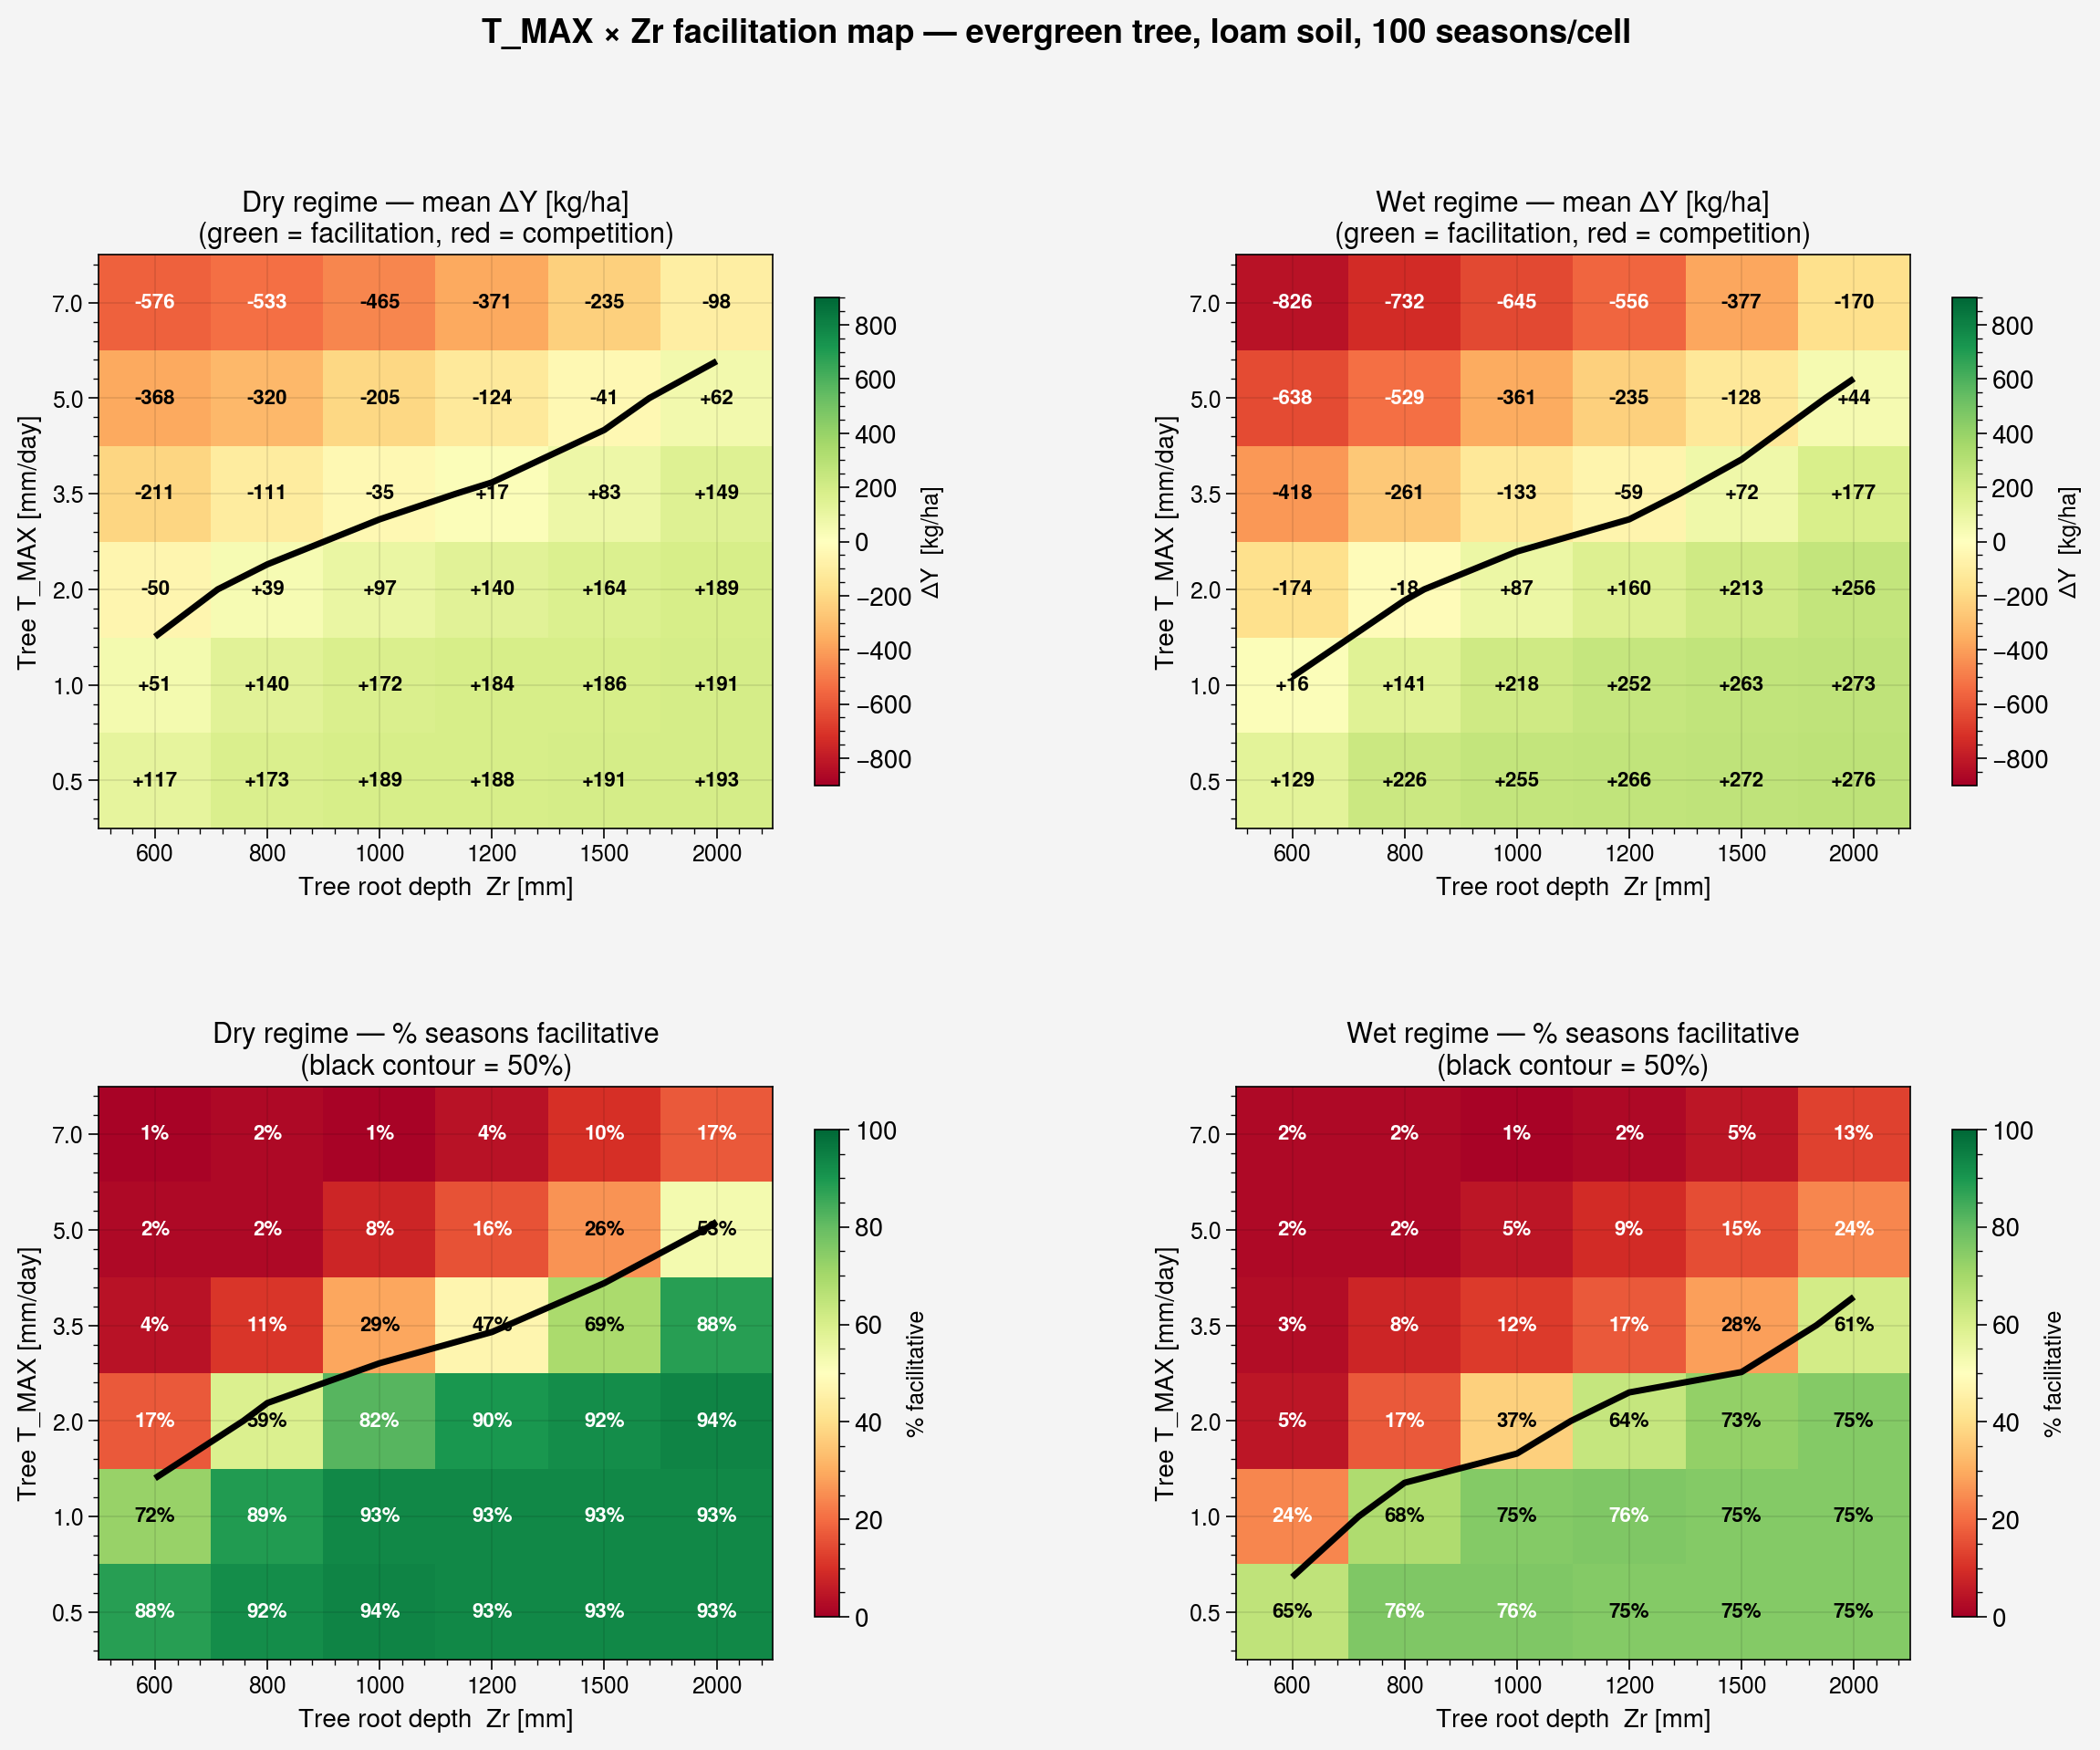

─── Facilitation boundary (50% threshold) ───

Dry regime:
  T_MAX=0.5: ≥50% facilitative when Zr ≥ 600 mm  (best cell ΔY = +193 kg/ha)
  T_MAX=1.0: ≥50% facilitative when Zr ≥ 600 mm  (best cell ΔY = +191 kg/ha)
  T_MAX=2.0: ≥50% facilitative when Zr ≥ 800 mm  (best cell ΔY = +189 kg/ha)
  T_MAX=3.5: ≥50% facilitative when Zr ≥ 1500 mm  (best cell ΔY = +149 kg/ha)
  T_MAX=5.0: ≥50% facilitative when Zr ≥ 2000 mm  (best cell ΔY = +62 kg/ha)
  T_MAX=7.0: ≥50% facilitative when Zr ≥ >2000 mm  (best cell ΔY = -98 kg/ha)

Wet regime:
  T_MAX=0.5: ≥50% facilitative when Zr ≥ 600 mm  (best cell ΔY = +276 kg/ha)
  T_MAX=1.0: ≥50% facilitative when Zr ≥ 800 mm  (best cell ΔY = +273 kg/ha)
  T_MAX=2.0: ≥50% facilitative when Zr ≥ 1200 mm  (best cell ΔY = +256 kg/ha)
  T_MAX=3.5: ≥50% facilitative when Zr ≥ 2000 mm  (best cell ΔY = +177 kg/ha)
  T_MAX=5.0: ≥50% facilitative when Zr ≥ >2000 mm  (best cell ΔY = +44 kg/ha)
  T_MAX=7.0: ≥50% facilitative when Zr ≥ >2000 mm  (best cell ΔY = -170 kg/h

In [10]:
T_labels = [str(t) for t in T_MAX_vals]
Z_labels = [str(z) for z in Zr_vals]
regime_list = list(REGIMES.keys())

vmax = max(np.abs(dY_mean[r]).max() for r in REGIMES)
vmax = np.ceil(vmax / 100) * 100  # round to nearest 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                         gridspec_kw={'hspace': 0.45, 'wspace': 0.35})

for col, regime in enumerate(regime_list):
    # ── Row 0: mean ΔY ───────────────────────────────────────────────────────
    ax = axes[0, col]
    mat = dY_mean[regime]
    im = ax.imshow(mat, cmap='RdYlGn', vmin=-vmax, vmax=vmax,
                   aspect='auto', origin='lower')
    if mat.min() < 0 < mat.max():
        ax.contour(mat, levels=[0], colors='k', linewidths=2.5)
    ax.set_xticks(range(nZ)); ax.set_xticklabels(Z_labels, fontsize=9)
    ax.set_yticks(range(nT)); ax.set_yticklabels(T_labels, fontsize=9)
    ax.set_xlabel('Tree root depth  Zr [mm]', fontsize=10)
    ax.set_ylabel('Tree T_MAX [mm/day]',       fontsize=10)
    ax.set_title(f'{regime} regime — mean ΔY [kg/ha]\n(green = facilitation, red = competition)',
                 fontsize=11)
    cb = plt.colorbar(im, ax=ax, shrink=0.85)
    cb.set_label('ΔY  [kg/ha]', fontsize=9)
    for ii in range(nT):
        for jj in range(nZ):
            v = mat[ii, jj]
            clr = 'white' if abs(v) > vmax * 0.55 else 'k'
            ax.text(jj, ii, f'{v:+.0f}', ha='center', va='center',
                    fontsize=8, fontweight='bold', color=clr)

    # ── Row 1: facilitation fraction ─────────────────────────────────────────
    ax = axes[1, col]
    frac = dY_frac[regime]
    im2 = ax.imshow(frac, cmap='RdYlGn', vmin=0, vmax=100,
                    aspect='auto', origin='lower')
    if frac.min() < 50 < frac.max():
        ax.contour(frac, levels=[50], colors='k', linewidths=2.5)
    ax.set_xticks(range(nZ)); ax.set_xticklabels(Z_labels, fontsize=9)
    ax.set_yticks(range(nT)); ax.set_yticklabels(T_labels, fontsize=9)
    ax.set_xlabel('Tree root depth  Zr [mm]', fontsize=10)
    ax.set_ylabel('Tree T_MAX [mm/day]',       fontsize=10)
    ax.set_title(f'{regime} regime — % seasons facilitative\n(black contour = 50%)',
                 fontsize=11)
    cb2 = plt.colorbar(im2, ax=ax, shrink=0.85)
    cb2.set_label('% facilitative', fontsize=9)
    for ii in range(nT):
        for jj in range(nZ):
            v = frac[ii, jj]
            clr = 'white' if v > 75 or v < 25 else 'k'
            ax.text(jj, ii, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, fontweight='bold', color=clr)

fig.suptitle('T_MAX × Zr facilitation map — evergreen tree, loam soil, 100 seasons/cell',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('../output/sweep_TMax_Zr.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
print("─── Facilitation boundary (50% threshold) ───")
for regime in REGIMES:
    print(f"\n{regime} regime:")
    for i, T_MAX in enumerate(T_MAX_vals):
        row = dY_frac[regime][i]
        crossing = next((Zr_vals[j] for j in range(nZ) if row[j] >= 50), ">2000")
        mean_best = dY_mean[regime][i].max()
        print(f"  T_MAX={T_MAX:.1f}: ≥50% facilitative when Zr ≥ {crossing} mm  "
              f"(best cell ΔY = {mean_best:+.0f} kg/ha)")

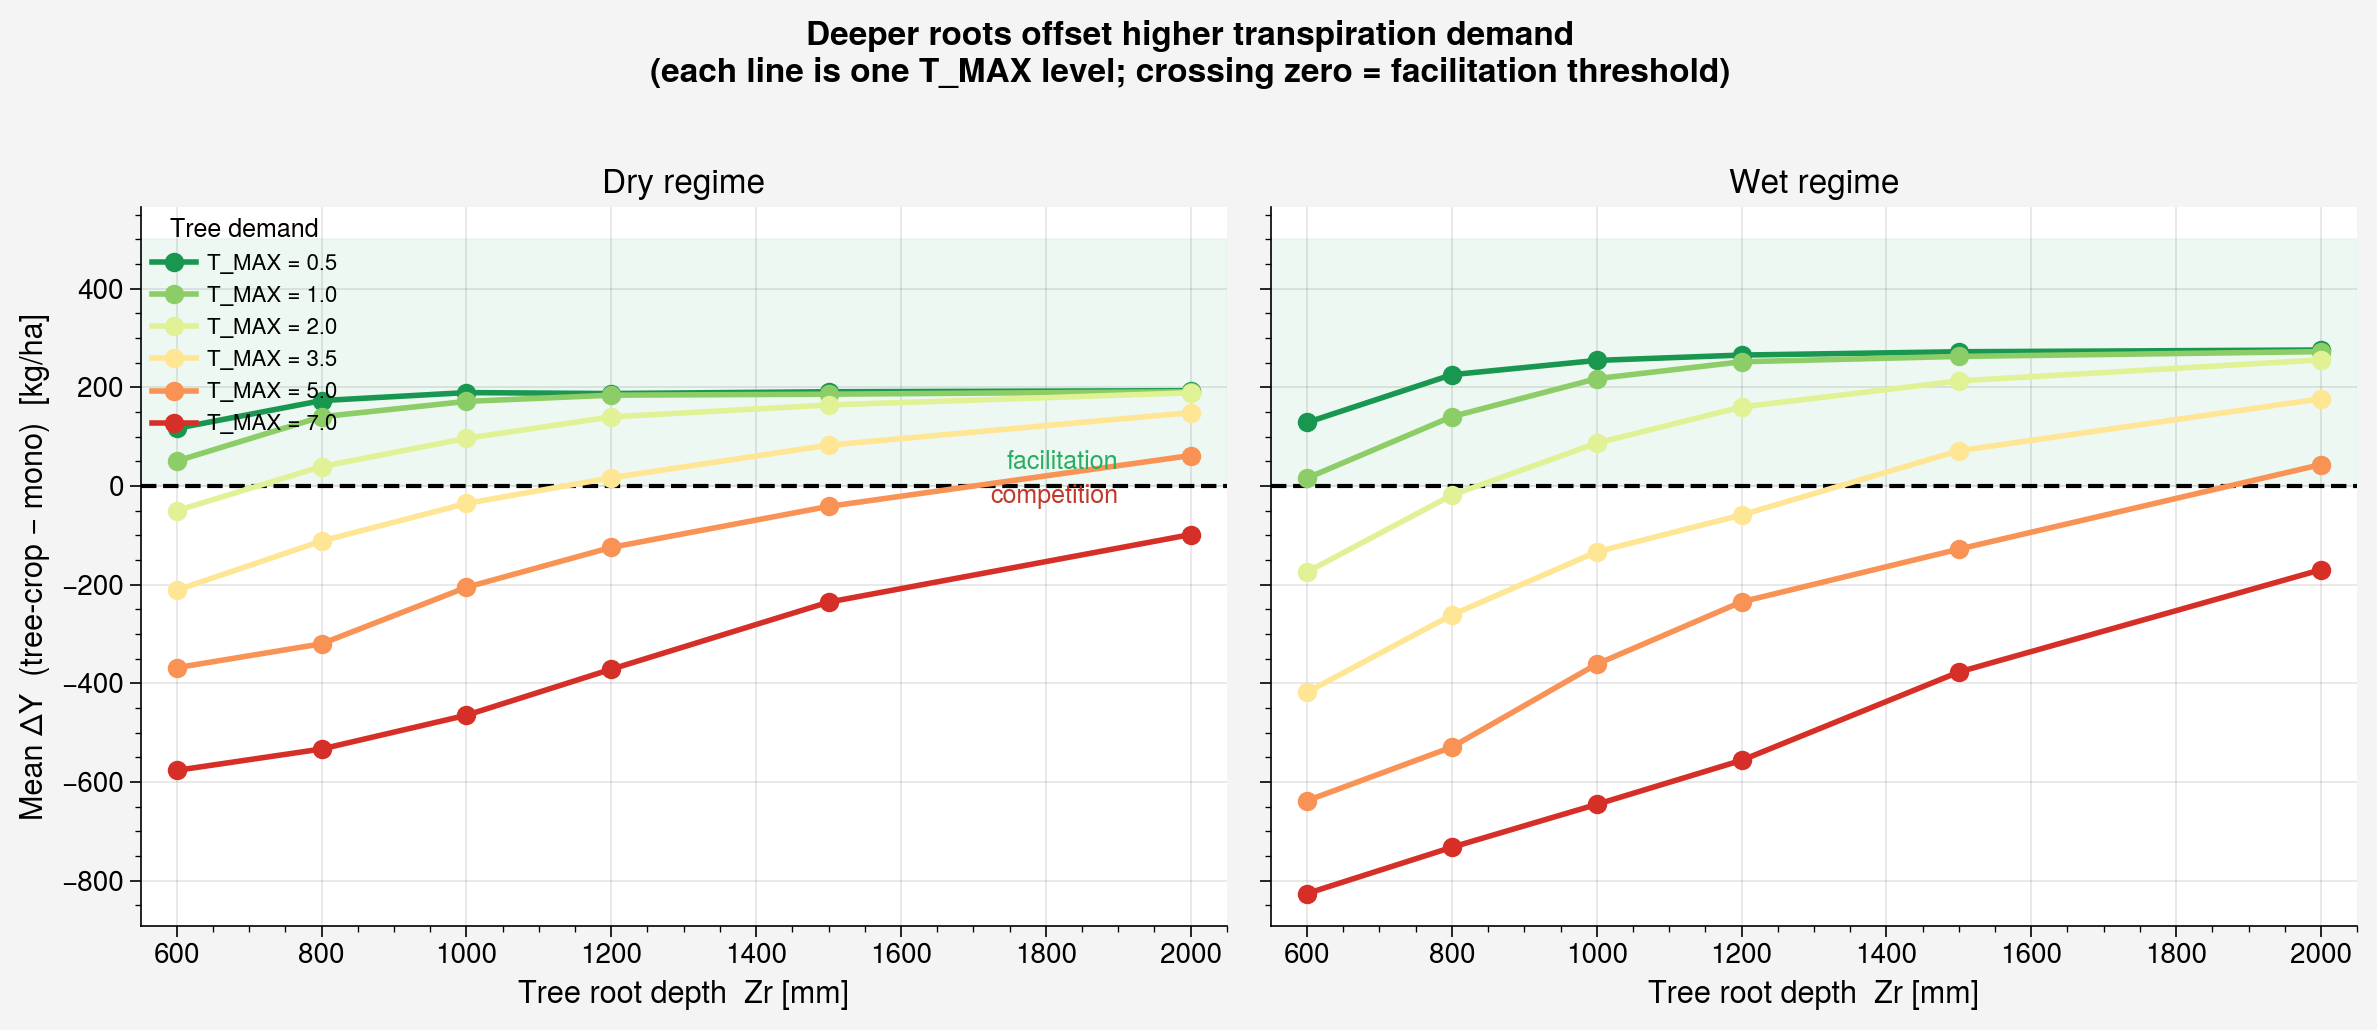

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

cmap   = plt.cm.RdYlGn_r
colors = [cmap(v) for v in np.linspace(0.1, 0.9, len(T_MAX_vals))]

for col, regime in enumerate(regime_list):
    ax = axes[col]
    ax.axhline(0, color='k', lw=1.5, ls='--', zorder=2)
    ax.axhspan(0, 500, color='#d4efdf', alpha=0.4, zorder=1)   # facilitation zone

    for i, T_MAX in enumerate(T_MAX_vals):
        ax.plot(Zr_vals, dY_mean[regime][i],
                color=colors[i], lw=2, marker='o', ms=6,
                label=f'T_MAX = {T_MAX}')

    ax.set_xlabel('Tree root depth  Zr [mm]', fontsize=11)
    ax.set_title(f'{regime} regime', fontsize=12)
    ax.set_xlim(550, 2050)
    despine(ax)

axes[0].set_ylabel('Mean ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
axes[0].legend(title='Tree demand', fontsize=8, title_fontsize=9,
               loc='upper left')

# shade label
axes[0].text(1900, 35, 'facilitation', color='#27ae60', fontsize=9, ha='right')
axes[0].text(1900, -35, 'competition', color='#c0392b', fontsize=9, ha='right')

fig.suptitle('Deeper roots offset higher transpiration demand\n'
             '(each line is one T_MAX level; crossing zero = facilitation threshold)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../output/sweep_TMax_Zr_simple.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Three trade-off figures

| # | Question | What varies |
|---|----------|-------------|
| 1 | Which mechanisms drive facilitation? | Each mechanism added in turn |
| 2 | How does total rainfall shift the balance? | Mean annual rainfall (α × λ scaled together) |
| 3 | Do storm structure matter independently of total rain? | Storm size α (λ inversely scaled → same mean rainfall) |

All three use the same three archetypes: **Faidherbia** (reverse phenology, Zr=1500, T_MAX=5), **Evergreen deep** (evergreen, Zr=1500, T_MAX=5), **Evergreen shallow** (evergreen, Zr=600, T_MAX=5). N=50 paired seasons each.

In [12]:
# ── Shared helpers for the 3 trade-off figures ───────────────────────────────

ARCHETYPES = {
    'Faidherbia':        dict(Zr=1500, T_MAX=1.0, kc=1.0, canopy_cover=0.2,
                              sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=0.0),
    'Evergreen deep':    dict(Zr=1500, T_MAX=4.0, kc=1.0, canopy_cover=0.2,
                              sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=1.0),
    'Evergreen shallow': dict(Zr=600,  T_MAX=4.0, kc=1.0, canopy_cover=0.3,
                              sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=1.0),
}

COLORS = {
    'Faidherbia':        '#27ae60',   # green — dormant during crop season
    'Evergreen deep':    '#e74c3c',   # red  — competes during full crop season
    'Evergreen shallow': '#e67e22',   # orange — shallow roots, competing all season
}

def _dY_array(tree_params, climate_obj, seeds, hr_max=1.0, s_deep_0=None, **run_kwargs):
    """Return array of (Y_tree_crop - Y_mono) for each seed.
    Uses paired simulations: same seed → same rainfall year for both models.
    Climate.rainfall is re-generated each seed so that different seeds produce
    different rainfall years (Climate stores a fixed array at init; without this
    all N simulations would use the same year and N would be effectively 1).
    run_kwargs (shade_on, hr_on, deep_roots) are forwarded to model.run().
    """
    sf_ = _tree_sf(tree_params)
    lgp = 180
    out = []
    for seed in seeds:
        # Re-generate rainfall from the stored climate parameters using this seed.
        # Both mono and tree-crop runs below share this same rainfall year.
        np.random.seed(seed)
        climate_obj.rainfall = Climate.generate(climate_obj.alpha_r, climate_obj.lambda_r)

        # ── monoculture ──────────────────────────────────────────────────────
        s_m = Soil(texture='loam'); c_m = Crop(soil=s_m); c_m.lgp = lgp
        s_m.set_nZr(c_m)
        m_m = CropModel(crop=c_m, climate=climate_obj, soil=s_m)
        m_m.run()
        df_m = m_m.output()
        _, _, y_m, _ = season_metrics(c_m, df_m, lgp)

        # ── tree-crop ────────────────────────────────────────────────────────
        s_t = Soil(texture='loam'); c_t = Crop(soil=s_t); c_t.lgp = lgp
        tr_ = Tree(soil=s_t, **tree_params)
        m_t = TreeCropModel(crop=c_t, tree=tr_, climate=climate_obj, soil=s_t, hr_max=hr_max)
        m_t.run(s_deep_0=s_deep_0, **run_kwargs)
        df_t = m_t.output()
        _, _, y_t, _ = season_metrics(c_t, df_t, lgp, sf=sf_)

        out.append(y_t - y_m)
    return np.array(out)


def _dY_array_annual(tree_params, climate_obj, seeds, hr_max=1.0, **run_kwargs):
    """Two back-to-back full years. Year-1 determines s_deep at planting
    endogenously from tree dry-season water use. Year-2 is the paired
    monoculture vs tree-crop comparison (same rainfall for both).
    Returns (dY_array, s_deep_at_planting_array).
    """
    sf_ = _tree_sf(tree_params)
    lgp = 180; t_after = 7
    t_before_full = 365 - lgp - t_after   # 178 days = full dry season
    dY_out   = []
    sdep_out = []
    for seed in seeds:
        # Year 1: tree-crop spinup — determines s_deep at planting endogenously
        np.random.seed(seed * 2)
        climate_obj.rainfall = Climate.generate(climate_obj.alpha_r, climate_obj.lambda_r)
        s_t1 = Soil(texture='loam'); c_t1 = Crop(soil=s_t1); c_t1.lgp = lgp
        m_t1 = TreeCropModel(crop=c_t1, tree=Tree(soil=s_t1, **tree_params),
                              climate=climate_obj, soil=s_t1, hr_max=hr_max)
        m_t1.run(t_before=t_before_full, t_after=t_after, **run_kwargs)
        s_deep_yr2 = m_t1.s_deep[-1]
        sdep_out.append(s_deep_yr2)

        # Year 2: paired analysis — same rainfall year for mono and tree-crop
        np.random.seed(seed * 2 + 1)
        climate_obj.rainfall = Climate.generate(climate_obj.alpha_r, climate_obj.lambda_r)

        s_m = Soil(texture='loam'); c_m = Crop(soil=s_m); c_m.lgp = lgp
        s_m.set_nZr(c_m)
        m_m = CropModel(crop=c_m, climate=climate_obj, soil=s_m)
        m_m.run(t_before=t_before_full)
        _, _, y_m, _ = season_metrics(c_m, m_m.output(), lgp)

        s_t2 = Soil(texture='loam'); c_t2 = Crop(soil=s_t2); c_t2.lgp = lgp
        m_t2 = TreeCropModel(crop=c_t2, tree=Tree(soil=s_t2, **tree_params),
                              climate=climate_obj, soil=s_t2, hr_max=hr_max)
        m_t2.run(t_before=t_before_full, t_after=t_after,
                 s_deep_0=s_deep_yr2, **run_kwargs)
        _, _, y_t, _ = season_metrics(c_t2, m_t2.output(), lgp, sf=sf_)

        dY_out.append(y_t - y_m)
    return np.array(dY_out), np.array(sdep_out)


print("Archetypes and helpers ready.")

Archetypes and helpers ready.


### Figure 1 — Mechanism waterfall

**Question:** which mechanisms explain facilitation, and by how much?

Two tree archetypes with **identical traits** (Zr=1500, T_MAX=5, canopy_cover=0.2) differing
only in phenology:
- **Co-season** (red): leafs out *with* the rains — competes and shades during crop season
- **Faidherbia** (green): *reverse* phenology — dormant and leafless during crop season

Four cumulative mechanism configurations (N=100 paired seasons, baseline climate):

| Config | What's active |
|--------|--------------|
| Competition only | shallow roots only, no shade, no HR |
| + Shade | shade reduces soil evaporation |
| + Deep roots | tree draws from exclusive deep-layer water |
| + HR | hydraulic redistribution lifts deep water into crop zone at night |

The growing gap between the two bars in each group isolates the **phenology timing effect**
from everything else.  Metric: mean ΔY [kg/ha].  Positive = facilitation; negative = competition.


Computing mechanism waterfall (N=100 per cell)...


Done in 5s

Faidherbia:
  Competition only                ΔY = -3 kg/ha
  +Shade                          ΔY = +2 kg/ha
  +Deep roots                     ΔY = +2 kg/ha
  +HR                             ΔY = +128 kg/ha

Evergreen deep:
  Competition only                ΔY = -46 kg/ha
  +Shade                          ΔY = +11 kg/ha
  +Deep roots                     ΔY = -87 kg/ha
  +HR                             ΔY = -14 kg/ha

Evergreen shallow:
  Competition only                ΔY = -71 kg/ha
  +Shade                          ΔY = +23 kg/ha
  +Deep roots                     ΔY = -576 kg/ha
  +HR                             ΔY = -576 kg/ha


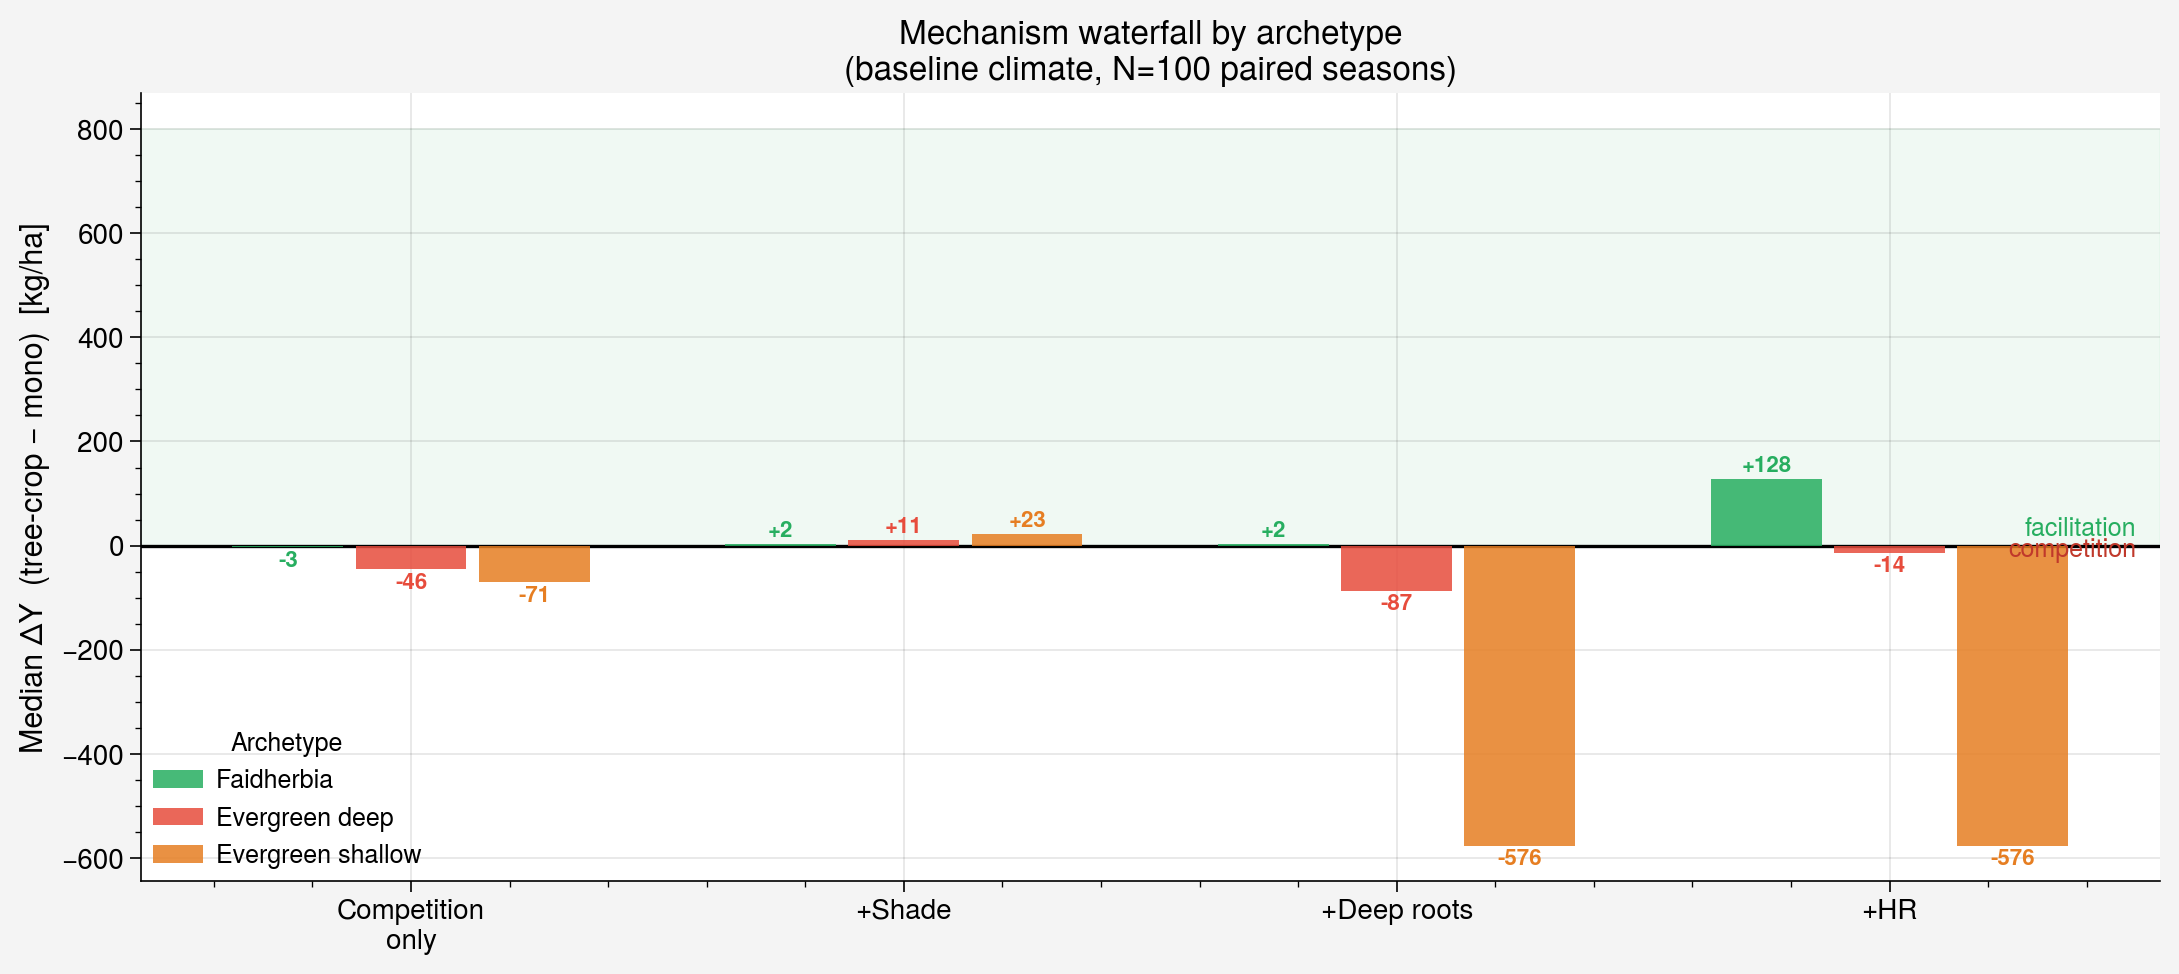

In [13]:
N_MECH = 100
SEEDS_MECH = list(range(N_MECH))
_cli_base = Climate()

# Mechanism configs — cumulative, in order of addition.
# Both trees keep their leaf_fraction throughout all steps.
MECHANISMS = [
    ('Competition\nonly',  dict(shade_on=False, hr_on=False, deep_roots=False)),
    ('+Shade',              dict(shade_on=True,  hr_on=False, deep_roots=False)),
    ('+Deep roots',         dict(shade_on=True,  hr_on=False, deep_roots=True)),
    ('+HR',                 dict(shade_on=True,  hr_on=True,  deep_roots=True)),
]

print("Computing mechanism waterfall (N=100 per cell)...")
t0 = time.time()

results = {}   # name → list of median ΔY for each mechanism step
for arch_name, arch_params in ARCHETYPES.items():
    dY_steps = []
    for step_label, run_kw in MECHANISMS:
        dY = _dY_array(arch_params, _cli_base, SEEDS_MECH, **run_kw)
        dY_steps.append(np.median(dY))
    results[arch_name] = dY_steps

print(f"Done in {time.time()-t0:.0f}s")
for name, steps in results.items():
    print(f"\n{name}:")
    for (lbl, _), v in zip(MECHANISMS, steps):
        print(f"  {lbl.replace(chr(10),' '):30s}  ΔY = {v:+.0f} kg/ha")

# ── Figure ──────────────────────────────────────────────────────────────────
n_arch = len(ARCHETYPES)
x = np.arange(len(MECHANISMS))
step_labels = [lbl for lbl, _ in MECHANISMS]
width = 0.25
offsets = np.linspace(-(n_arch - 1) / 2, (n_arch - 1) / 2, n_arch) * width

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, color='k', lw=1.2, zorder=2)
ax.axhspan(0, 800, color='#d4efdf', alpha=0.35, zorder=1)

for idx, (arch_name, dY_steps) in enumerate(results.items()):
    bars = ax.bar(x + offsets[idx], dY_steps,
                  width=width * 0.9,
                  color=COLORS[arch_name],
                  alpha=0.85,
                  label=arch_name,
                  zorder=3)
    # value labels
    for bar, v in zip(bars, dY_steps):
        va = 'bottom' if v >= 0 else 'top'
        yoff = 5 if v >= 0 else -5
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + yoff,
                f'{v:+.0f}', ha='center', va=va, fontsize=8,
                color=COLORS[arch_name], fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(step_labels, fontsize=10)
ax.set_ylabel('Median ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
ax.set_title('Mechanism waterfall by archetype\n'
             '(baseline climate, N=100 paired seasons)', fontsize=12)
ax.legend(title='Archetype', fontsize=9, title_fontsize=9)

# annotation
ax.text(x[-1] + 0.5, 20,  'facilitation', color='#27ae60', fontsize=9, ha='right')
ax.text(x[-1] + 0.5, -20, 'competition',  color='#c0392b', fontsize=9, ha='right')

despine(ax)
plt.tight_layout()
plt.savefig('../output/fig1_mechanism_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


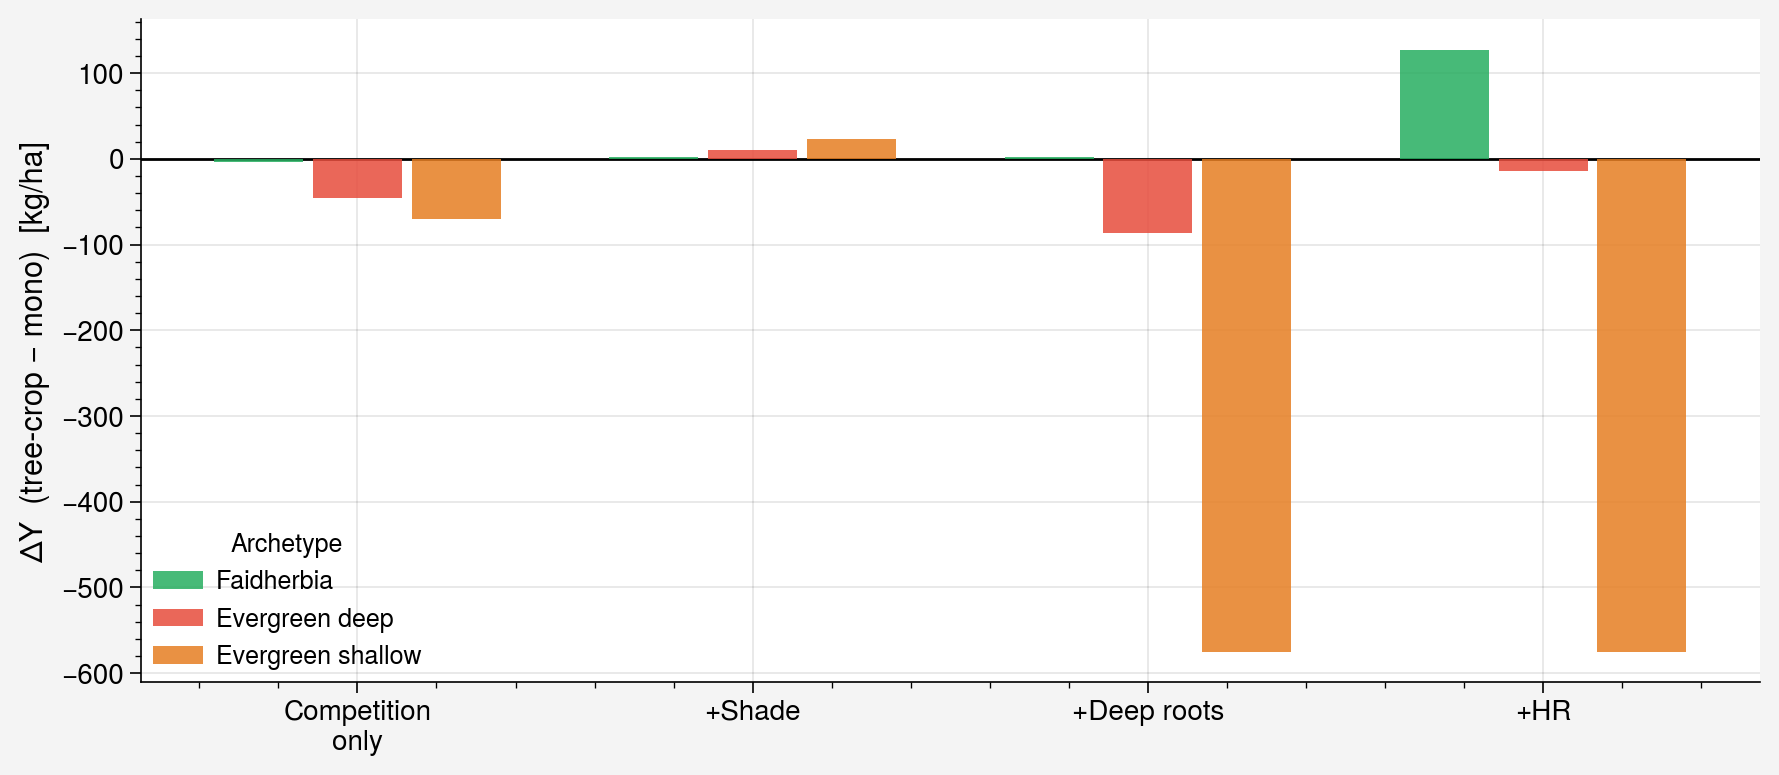

In [14]:
n_arch = len(ARCHETYPES)
fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(0, color='k', lw=1, zorder=2)

x = np.arange(len(MECHANISMS))
step_labels = ['Competition\nonly', '+Shade', '+Deep roots', '+HR']
width = 0.25
offsets = np.linspace(-(n_arch - 1) / 2, (n_arch - 1) / 2, n_arch) * width

for idx, (arch_name, dY_steps) in enumerate(results.items()):
    ax.bar(x + offsets[idx], dY_steps,
           width=width * 0.9,
           color=COLORS[arch_name],
           alpha=0.85,
           label=arch_name,
           zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(step_labels, fontsize=10)
ax.set_ylabel('ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
ax.legend(title='Archetype', fontsize=9, title_fontsize=9, frameon=False)
despine(ax)
plt.tight_layout()
plt.savefig('../output/fig1_mechanism_waterfall_simple.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 2 — Mean annual rainfall sweep

**Question:** does higher total rainfall shift trees from competitors to facilitators?

Scale both α (storm size) and λ (storm frequency) by the same factor → MAP changes proportionally.
Each archetype runs in its full configuration (shade + deep roots + HR + native phenology).
N=50 paired seasons per regime point.

Computing MAP sweep (N=50 per archetype × scale)...


Done in 17s


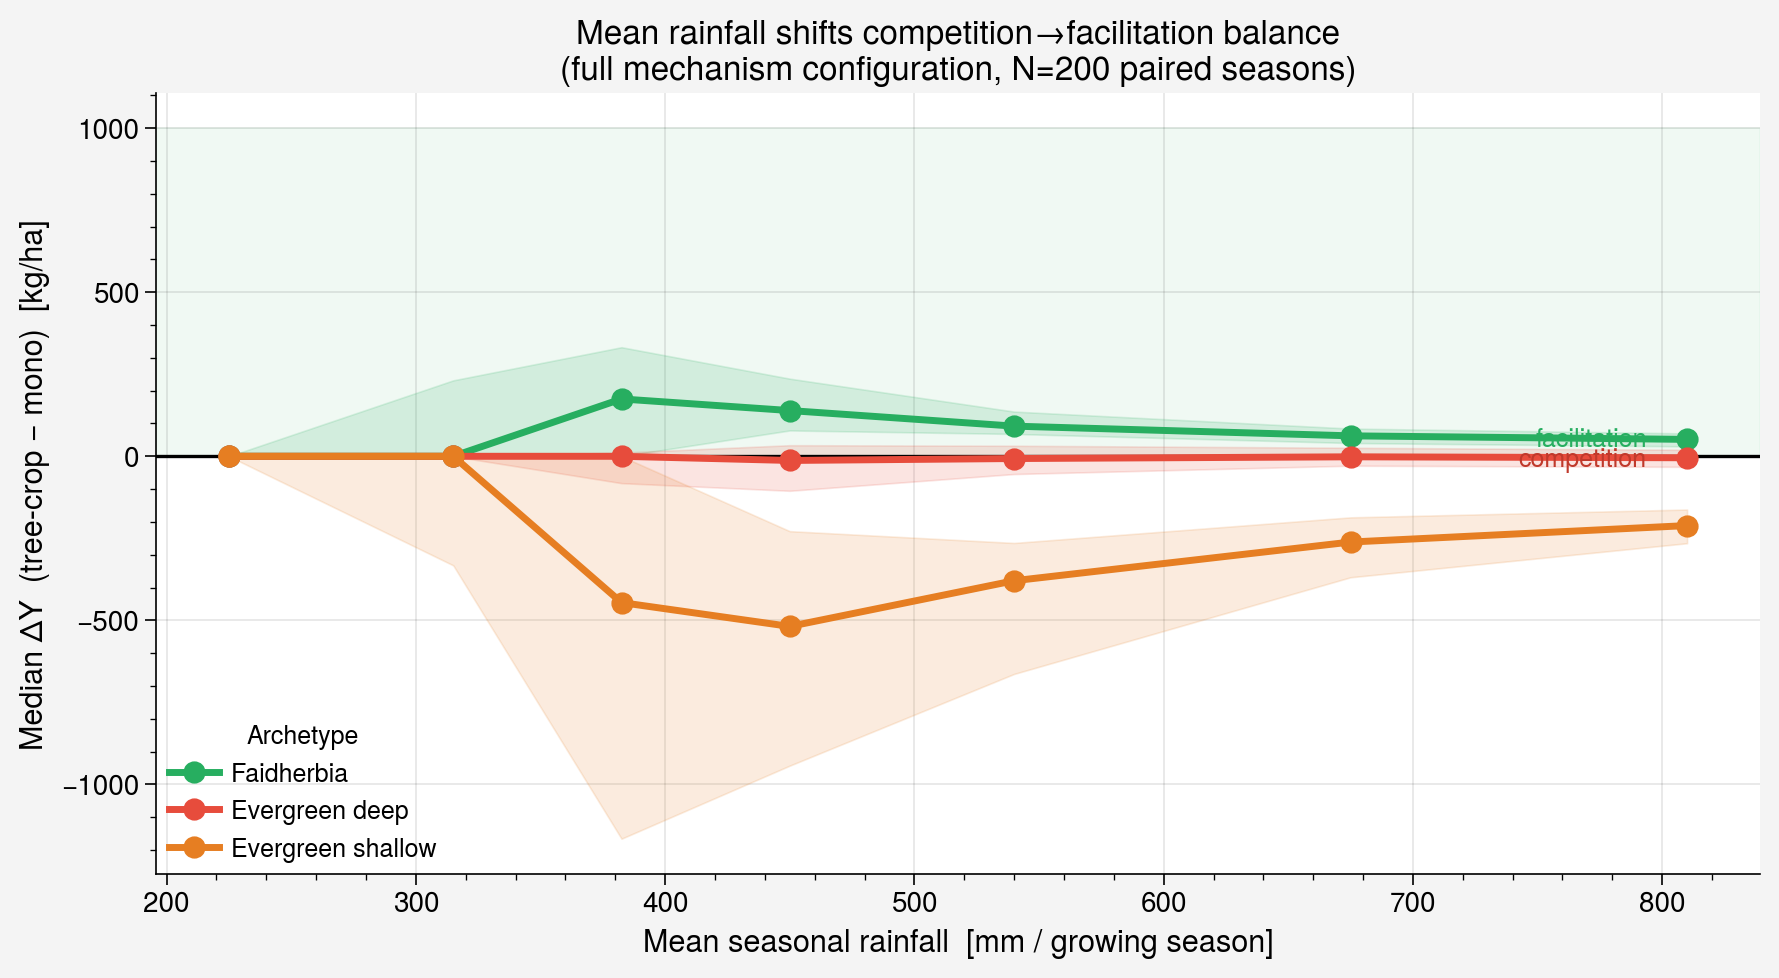


ΔY at each scale:
  Faidherbia:
    225 mm/season  →  median ΔY = +0 kg/ha  [+0, +0]
    315 mm/season  →  median ΔY = +0 kg/ha  [+0, +232]
    382 mm/season  →  median ΔY = +175 kg/ha  [+0, +332]
    450 mm/season  →  median ΔY = +139 kg/ha  [+79, +237]
    540 mm/season  →  median ΔY = +92 kg/ha  [+68, +136]
    675 mm/season  →  median ΔY = +62 kg/ha  [+40, +85]
    810 mm/season  →  median ΔY = +52 kg/ha  [+30, +70]
  Evergreen deep:
    225 mm/season  →  median ΔY = +0 kg/ha  [+0, +0]
    315 mm/season  →  median ΔY = +0 kg/ha  [+0, +0]
    382 mm/season  →  median ΔY = +0 kg/ha  [-82, +11]
    450 mm/season  →  median ΔY = -13 kg/ha  [-105, +34]
    540 mm/season  →  median ΔY = -7 kg/ha  [-54, +32]
    675 mm/season  →  median ΔY = -2 kg/ha  [-29, +26]
    810 mm/season  →  median ΔY = -4 kg/ha  [-32, +20]
  Evergreen shallow:
    225 mm/season  →  median ΔY = +0 kg/ha  [+0, +0]
    315 mm/season  →  median ΔY = +0 kg/ha  [-333, +0]
    382 mm/season  →  median ΔY = -446 kg/ha 

In [15]:
N_MAP  = 200
SEEDS_MAP = list(range(N_MAP))
RF_SCALES = [0.5, 0.7, 0.85, 1.0, 1.2, 1.5, 1.8]  # multiplier on α AND λ

# Compute mean seasonal rainfall at each scale (day 0-365, lgp=180 season)
_cli_ref = Climate()
_alpha_mean = np.mean(_cli_ref.alpha_r)     # mean storm depth (mm)
_lambda_mean = np.mean(_cli_ref.lambda_r)   # mean storm rate (day^-1)
MAP_mm = [s * _alpha_mean * s * _lambda_mean * 365 for s in RF_SCALES]
# Simpler: mean seasonal rain = alpha * lambda * lgp  (just for x-axis label)
SEASON_RAIN = [s * s * _alpha_mean * _lambda_mean * 180 for s in RF_SCALES]
# Actually: scale both, so seasonal rain ∝ s^2? No — if we scale α by s and λ by s,
# E[R] = α*λ scales as s^2. But the intent is a 1D MAP axis:
# Let's scale only α (storm size) by the sweep factor, keeping λ fixed.
# That way E[seasonal rain] = alpha_scale * lambda * lgp  ∝ s  (linear in x-axis)
SEASON_RAIN_mm = [s * _alpha_mean * _lambda_mean * 180 for s in RF_SCALES]

print("Computing MAP sweep (N=50 per archetype × scale)...")
t0 = time.time()

map_results = {}   # arch_name → array shape (n_scales, 3): p25, median, p75
for arch_name, arch_params in ARCHETYPES.items():
    rows = []
    for scale in RF_SCALES:
        cli_ = Climate(
            alpha_r  = [a * scale for a in _cli_ref.alpha_r],
            lambda_r = _cli_ref.lambda_r,   # frequency unchanged
            ET_max   = _cli_ref.ET_max,
        )
        dY = _dY_array(arch_params, cli_, SEEDS_MAP,
                       shade_on=True, hr_on=True, deep_roots=True)
        rows.append([np.percentile(dY, 25), np.median(dY), np.percentile(dY, 75)])
    map_results[arch_name] = np.array(rows)

print(f"Done in {time.time()-t0:.0f}s")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color='k', lw=1.2, zorder=2)
ax.axhspan(0, 1000, color='#d4efdf', alpha=0.35, zorder=1)

for arch_name, data in map_results.items():
    p25, p50, p75 = data[:,0], data[:,1], data[:,2]
    ax.plot(SEASON_RAIN_mm, p50,
            color=COLORS[arch_name], lw=2.5, marker='o', ms=7,
            label=arch_name, zorder=3)
    ax.fill_between(SEASON_RAIN_mm, p25, p75,
                    color=COLORS[arch_name], alpha=0.15, zorder=2)

ax.set_xlabel('Mean seasonal rainfall  [mm / growing season]', fontsize=11)
ax.set_ylabel('Median ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
ax.set_title('Mean rainfall shifts competition→facilitation balance\n'
             '(full mechanism configuration, N=200 paired seasons)', fontsize=12)
ax.legend(title='Archetype', fontsize=9, title_fontsize=9)
ax.text(SEASON_RAIN_mm[-1]*0.98, 30,  'facilitation', color='#27ae60', fontsize=9, ha='right')
ax.text(SEASON_RAIN_mm[-1]*0.98, -30, 'competition',  color='#c0392b', fontsize=9, ha='right')
despine(ax)
plt.tight_layout()
plt.savefig('../output/fig2_MAP_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nΔY at each scale:")
for arch_name, data in map_results.items():
    print(f"  {arch_name}:")
    for sr, row in zip(SEASON_RAIN_mm, data):
        print(f"    {sr:.0f} mm/season  →  median ΔY = {row[1]:+.0f} kg/ha  [{row[0]:+.0f}, {row[2]:+.0f}]")

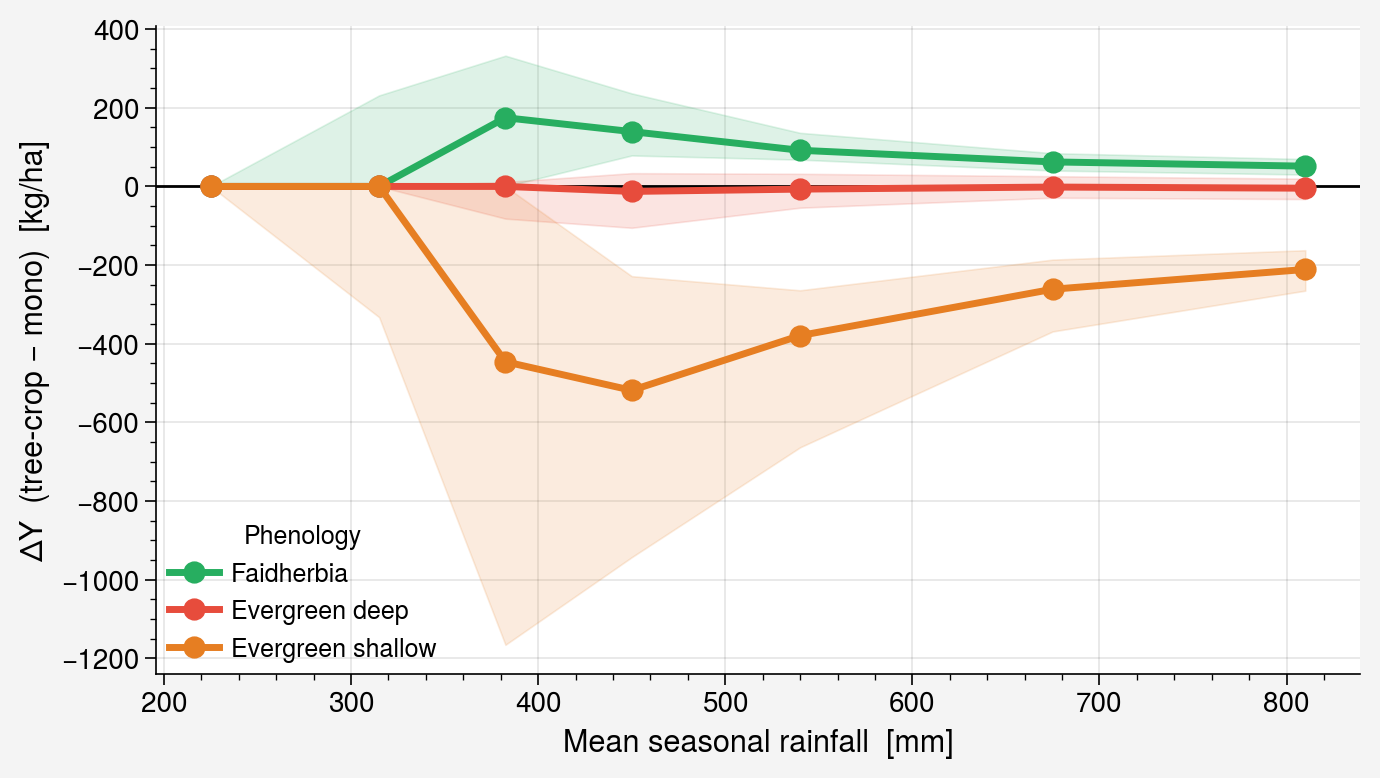

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, color='k', lw=1, zorder=2)

for arch_name, data in map_results.items():
    p25, p50, p75 = data[:,0], data[:,1], data[:,2]
    ax.plot(SEASON_RAIN_mm, p50, color=COLORS[arch_name], lw=2.5,
            marker='o', ms=7, label=arch_name, zorder=3)
    ax.fill_between(SEASON_RAIN_mm, p25, p75,
                    color=COLORS[arch_name], alpha=0.15, zorder=2)

ax.set_xlabel('Mean seasonal rainfall  [mm]', fontsize=11)
ax.set_ylabel('ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
ax.legend(title='Phenology', fontsize=9, title_fontsize=9, frameon=False)
despine(ax)
plt.tight_layout()
plt.savefig('../output/fig2_MAP_sweep_simple.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 7 — Phenology × rainfall heatmap

**Question:** which combinations of leaf timing and rainfall regime produce facilitation vs competition?

2D grid: `leaf_fraction` ∈ {0.0, 0.2, 0.4, 0.6, 0.8, 1.0} × mean seasonal rainfall (7 levels matching Fig 2 x-axis), N=200 paired seasons per cell.

Color: median ΔY (kg/ha); diverging colormap (blue = facilitation, red = competition).  
Black dashed contour: ΔY = 0 boundary.  
Stars: observed species (Faidherbia albida, Grevillea robusta, Leucaena).

Fixed parameters: Zr=1500, T_MAX=1.0, canopy_cover=0.2, full mechanisms (HR + shade + deep roots).


Computing phenology x rainfall heatmap  (6 x 7 grid x 200 seasons = 8,400 runs)...


  lf=0.0  median dY: +0 to +150 kg/ha


  lf=0.2  median dY: +0 to +125 kg/ha


  lf=0.4  median dY: +0 to +78 kg/ha


  lf=0.6  median dY: +0 to +47 kg/ha


  lf=0.8  median dY: +0 to +16 kg/ha


  lf=1.0  median dY: -13 to +0 kg/ha
Done in 36s


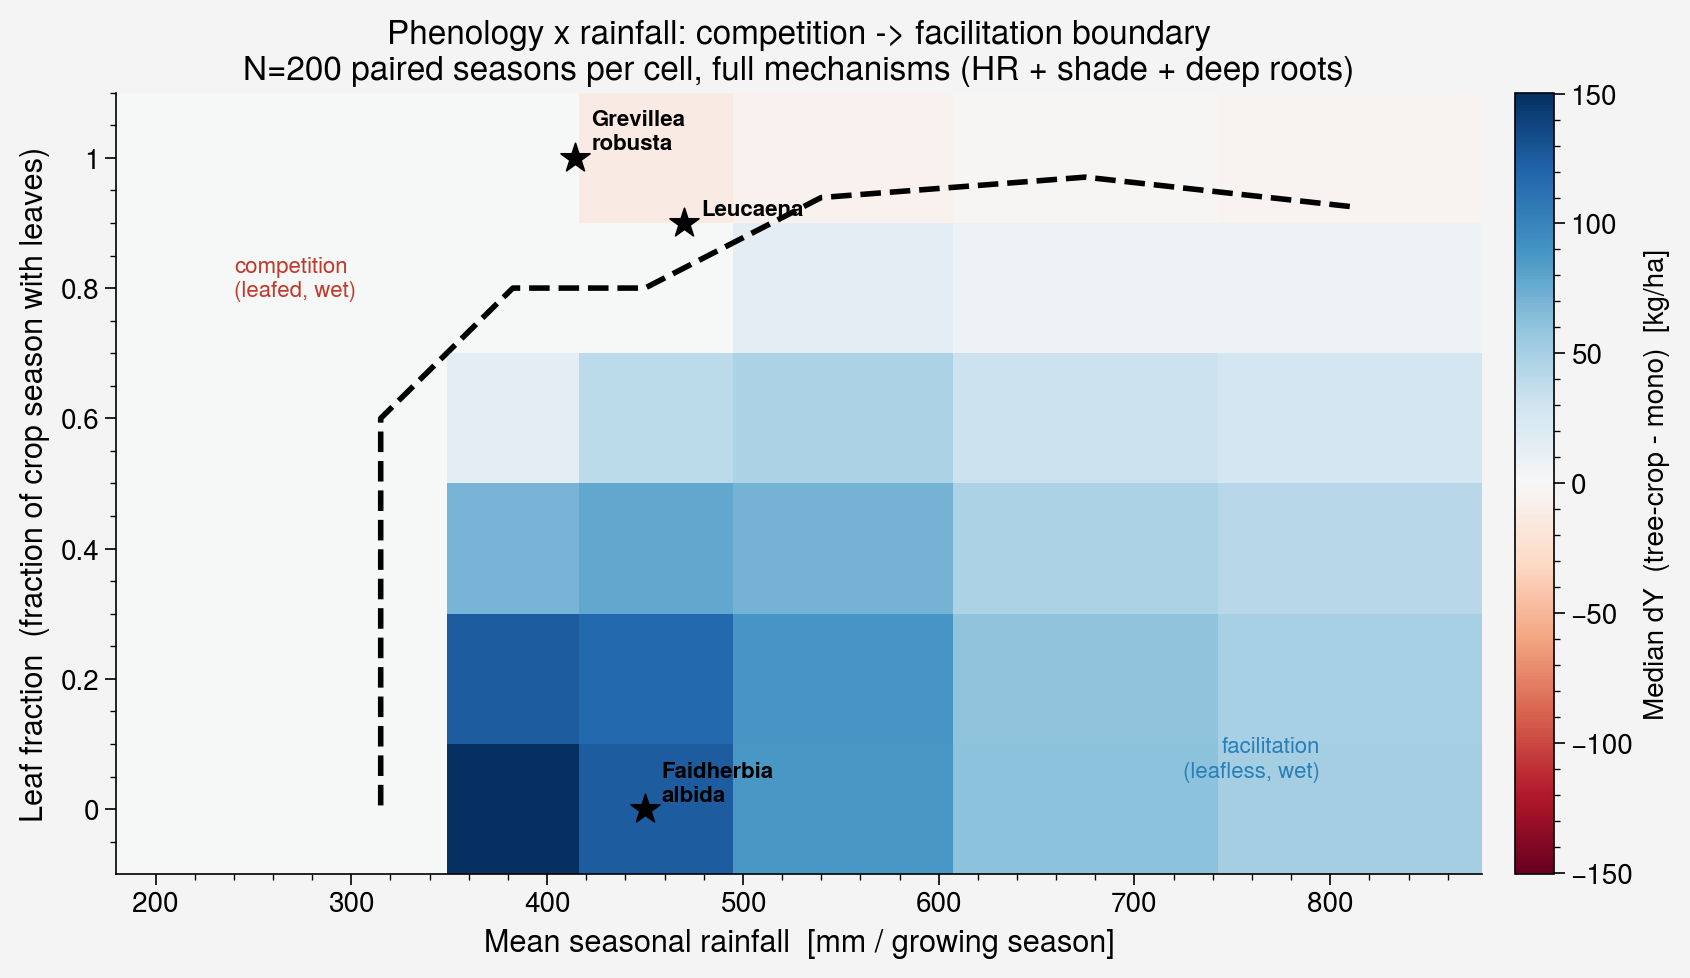


Heatmap values (median dY kg/ha):
 lf/RF    225    315    382    450    540    675    810
   0.0     +0     +0   +150   +125    +87    +61    +52
   0.2     +0     +0   +125   +119    +88    +61    +50
   0.4     +0     +0    +70    +78    +71    +48    +42
   0.6     +0     +0    +16    +41    +47    +32    +28
   0.8     +0     +0     +0     +0    +16     +9     +7
   1.0     +0     +0     +0    -13     -7     -2     -4


In [17]:
# ── Phenology × rainfall heatmap ─────────────────────────────────────────────
# RF_SCALES and SEASON_RAIN_mm defined in Fig 2 cell above.
# _dY_array defined in the shared helpers cell.

LF_VALS     = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]   # leaf_fraction axis
N_PHENO     = 200
SEEDS_PHENO = list(range(N_PHENO))

# Base tree params for sweep (only leaf_fraction varies)
_base_tp_ph = dict(Zr=1500, T_MAX=4.0, kc=1.0, canopy_cover=0.2,
                   sw_MPa=-2.0, s_star_MPa=-0.1)

_cli_ref_ph = Climate()

print(f"Computing phenology x rainfall heatmap  "
      f"({len(LF_VALS)} x {len(RF_SCALES)} grid x {N_PHENO} seasons = "
      f"{len(LF_VALS) * len(RF_SCALES) * N_PHENO:,} runs)...")
t0 = time.time()

# heatmap_data: rows = LF_VALS (leaf_fraction), cols = RF_SCALES (rainfall)
heatmap_data = np.zeros((len(LF_VALS), len(RF_SCALES)))

for j, lf in enumerate(LF_VALS):
    for k, scale in enumerate(RF_SCALES):
        tp = {**_base_tp_ph, "leaf_fraction": lf}
        cli_ = Climate(
            alpha_r  = [a * scale for a in _cli_ref_ph.alpha_r],
            lambda_r = _cli_ref_ph.lambda_r,   # frequency unchanged -> linear MAP axis
            ET_max   = _cli_ref_ph.ET_max,
        )
        dY = _dY_array(tp, cli_, SEEDS_PHENO,
                       shade_on=True, hr_on=True, deep_roots=True)
        heatmap_data[j, k] = np.median(dY)
    print(f"  lf={lf:.1f}  median dY: {heatmap_data[j].min():+.0f} to {heatmap_data[j].max():+.0f} kg/ha")

print(f"Done in {time.time()-t0:.0f}s")

# ── Figure ───────────────────────────────────────────────────────────────────
vmax = max(abs(heatmap_data.min()), abs(heatmap_data.max()))

fig, ax = plt.subplots(figsize=(9, 5))

im = ax.pcolormesh(SEASON_RAIN_mm, LF_VALS, heatmap_data,
                   cmap='RdBu', vmin=-vmax, vmax=vmax,
                   shading='nearest')

# dY = 0 contour -- competition/facilitation boundary
try:
    ax.contour(SEASON_RAIN_mm, LF_VALS, heatmap_data,
               levels=[0], colors='k', linewidths=2.0, linestyles='--')
except Exception:
    pass  # no contour if no sign change in grid

# ── Species overlay ───────────────────────────────────────────────────────────
# x = mean seasonal rainfall (mm); y = leaf_fraction during crop season
# Rainfall values from site literature (MAP converted to seasonal fraction):
#   Faidherbia: Laikipia ~450 mm/season (Roupsard 1999, Sarr 2023)
#   Grevillea:  Machakos ~414 mm/season (Ong et al.)
#   Leucaena:   Laikipia ~470 mm/season (Waweru)
species_pts = [
    ("Faidherbia\nalbida",   0.0,  450),
    ("Grevillea\nrobusta",   1.0,  414),
    ("Leucaena",             0.9,  470),
]
for name, lf, rain_mm in species_pts:
    ax.scatter(rain_mm, lf, s=120, color='k', zorder=6, marker='*')
    ax.annotate(name, (rain_mm, lf), fontsize=8,
                xytext=(6, 3), textcoords='offset points', color='k',
                fontweight='bold')

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Median dY  (tree-crop - mono)  [kg/ha]', fontsize=10)

ax.set_xlabel('Mean seasonal rainfall  [mm / growing season]', fontsize=11)
ax.set_ylabel('Leaf fraction  (fraction of crop season with leaves)', fontsize=11)
ax.set_yticks(LF_VALS)
ax.set_title('Phenology x rainfall: competition -> facilitation boundary\n'
             'N={} paired seasons per cell, full mechanisms (HR + shade + deep roots)'.format(N_PHENO),
             fontsize=12)

# Quadrant labels
ax.text(SEASON_RAIN_mm[0] + 15, 0.85, 'competition\n(leafed, wet)',
        color='#c0392b', fontsize=8, va='top')
ax.text(SEASON_RAIN_mm[-1] - 15, 0.05, 'facilitation\n(leafless, wet)',
        color='#2980b9', fontsize=8, ha='right')

despine(ax)
plt.tight_layout()
plt.savefig('../output/fig7_pheno_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHeatmap values (median dY kg/ha):")
_hdr = "lf/RF"
print("{:>6s}".format(_hdr), *["{:>6.0f}".format(v) for v in SEASON_RAIN_mm])
for j, lf in enumerate(LF_VALS):
    print("{:>6.1f}".format(lf), *["{:>+6.0f}".format(heatmap_data[j, k]) for k in range(len(RF_SCALES))])


### Figure 3 — Storm structure sweep (constant mean rainfall)

**Question:** do large infrequent storms favor facilitation differently than many small storms?

Fix mean seasonal rainfall = baseline (α × λ constant), but vary storm size α up and
frequency λ down (or vice versa). This isolates the *temporal distribution* of rainfall
from the total amount.

- **Large storms** (high α, low λ): long dry intervals → s_top crashes → HR kicks in strongly
- **Small frequent storms** (low α, high λ): s_top stays moist → tree competes for shallow water; little HR gradient

N=50 paired seasons per storm-structure point.

Computing storm structure sweep (N=50 per archetype × scale)...


Done in 17s


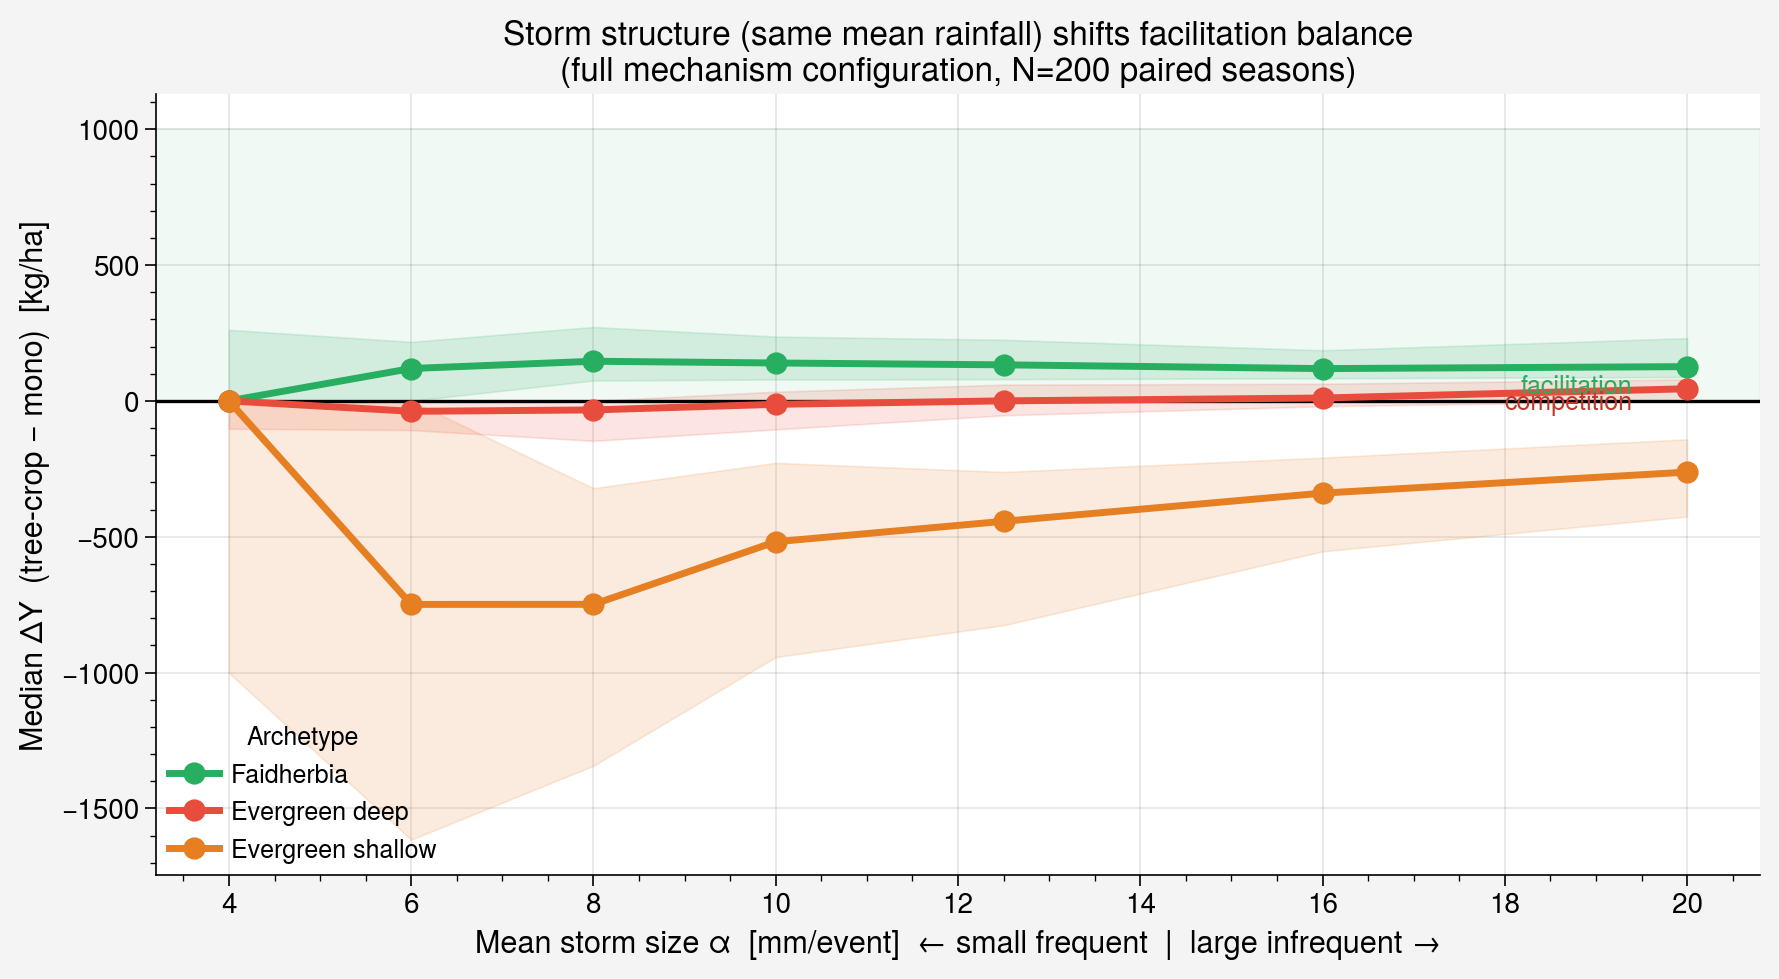


ΔY at each storm structure:
  Faidherbia:
    α = 4.0 mm/event  →  median ΔY = +0 kg/ha  [+0, +261]
    α = 6.0 mm/event  →  median ΔY = +119 kg/ha  [+0, +217]
    α = 8.0 mm/event  →  median ΔY = +146 kg/ha  [+75, +272]
    α = 10.0 mm/event  →  median ΔY = +139 kg/ha  [+79, +237]
    α = 12.5 mm/event  →  median ΔY = +133 kg/ha  [+80, +225]
    α = 16.0 mm/event  →  median ΔY = +119 kg/ha  [+83, +186]
    α = 20.0 mm/event  →  median ΔY = +126 kg/ha  [+88, +231]
  Evergreen deep:
    α = 4.0 mm/event  →  median ΔY = +0 kg/ha  [-103, +0]
    α = 6.0 mm/event  →  median ΔY = -38 kg/ha  [-108, +0]
    α = 8.0 mm/event  →  median ΔY = -33 kg/ha  [-147, +0]
    α = 10.0 mm/event  →  median ΔY = -13 kg/ha  [-105, +34]
    α = 12.5 mm/event  →  median ΔY = +0 kg/ha  [-53, +60]
    α = 16.0 mm/event  →  median ΔY = +10 kg/ha  [-20, +63]
    α = 20.0 mm/event  →  median ΔY = +45 kg/ha  [+0, +79]
  Evergreen shallow:
    α = 4.0 mm/event  →  median ΔY = +0 kg/ha  [-1001, +0]
    α = 6.0 mm/ev

In [18]:
N_STRUCT  = 200
SEEDS_STRUCT = list(range(N_STRUCT))

# α_scale × (1/α_scale) keeps E[rain] = α*λ constant
# α_scale > 1 → larger, rarer storms; α_scale < 1 → smaller, more frequent
STRUCT_SCALES = [0.4, 0.6, 0.8, 1.0, 1.25, 1.6, 2.0]   # α multiplier
STORM_SIZE_mm = [s * _alpha_mean for s in STRUCT_SCALES]  # actual mean storm depth (mm)

print("Computing storm structure sweep (N=50 per archetype × scale)...")
t0 = time.time()

struct_results = {}
for arch_name, arch_params in ARCHETYPES.items():
    rows = []
    for scale in STRUCT_SCALES:
        cli_ = Climate(
            alpha_r  = [a * scale       for a in _cli_ref.alpha_r],
            lambda_r = [l / scale       for l in _cli_ref.lambda_r],  # constant mean rain
            ET_max   = _cli_ref.ET_max,
        )
        dY = _dY_array(arch_params, cli_, SEEDS_STRUCT,
                       shade_on=True, hr_on=True, deep_roots=True)
        rows.append([np.percentile(dY, 25), np.median(dY), np.percentile(dY, 75)])
    struct_results[arch_name] = np.array(rows)

print(f"Done in {time.time()-t0:.0f}s")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color='k', lw=1.2, zorder=2)
ax.axhspan(0, 1000, color='#d4efdf', alpha=0.35, zorder=1)

for arch_name, data in struct_results.items():
    p25, p50, p75 = data[:,0], data[:,1], data[:,2]
    ax.plot(STORM_SIZE_mm, p50,
            color=COLORS[arch_name], lw=2.5, marker='o', ms=7,
            label=arch_name, zorder=3)
    ax.fill_between(STORM_SIZE_mm, p25, p75,
                    color=COLORS[arch_name], alpha=0.15, zorder=2)

ax.set_xlabel('Mean storm size α  [mm/event]  ← small frequent  |  large infrequent →',
              fontsize=11)
ax.set_ylabel('Median ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
ax.set_title('Storm structure (same mean rainfall) shifts facilitation balance\n'
             '(full mechanism configuration, N=200 paired seasons)', fontsize=12)
ax.legend(title='Archetype', fontsize=9, title_fontsize=9)
ax.text(STORM_SIZE_mm[-1]*0.97, 30,  'facilitation', color='#27ae60', fontsize=9, ha='right')
ax.text(STORM_SIZE_mm[-1]*0.97, -30, 'competition',  color='#c0392b', fontsize=9, ha='right')
despine(ax)
plt.tight_layout()
plt.savefig('../output/fig3_storm_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nΔY at each storm structure:")
for arch_name, data in struct_results.items():
    print(f"  {arch_name}:")
    for ss, row in zip(STORM_SIZE_mm, data):
        print(f"    α = {ss:.1f} mm/event  →  median ΔY = {row[1]:+.0f} kg/ha  [{row[0]:+.0f}, {row[2]:+.0f}]")

### Figure 4 — HR sensitivity

**Question:** how much hydraulic redistribution capacity does Faidherbia need to facilitate?

Sweep `hr_max` from 0 (no HR) to 1.0 mm/day (upper literature bound). Full mechanism
configuration otherwise (shade + deep roots). N=200, baseline climate. IQR band = 25th–75th percentile.

Computing HR sensitivity sweep (N=200 per point)...


Done in 17s


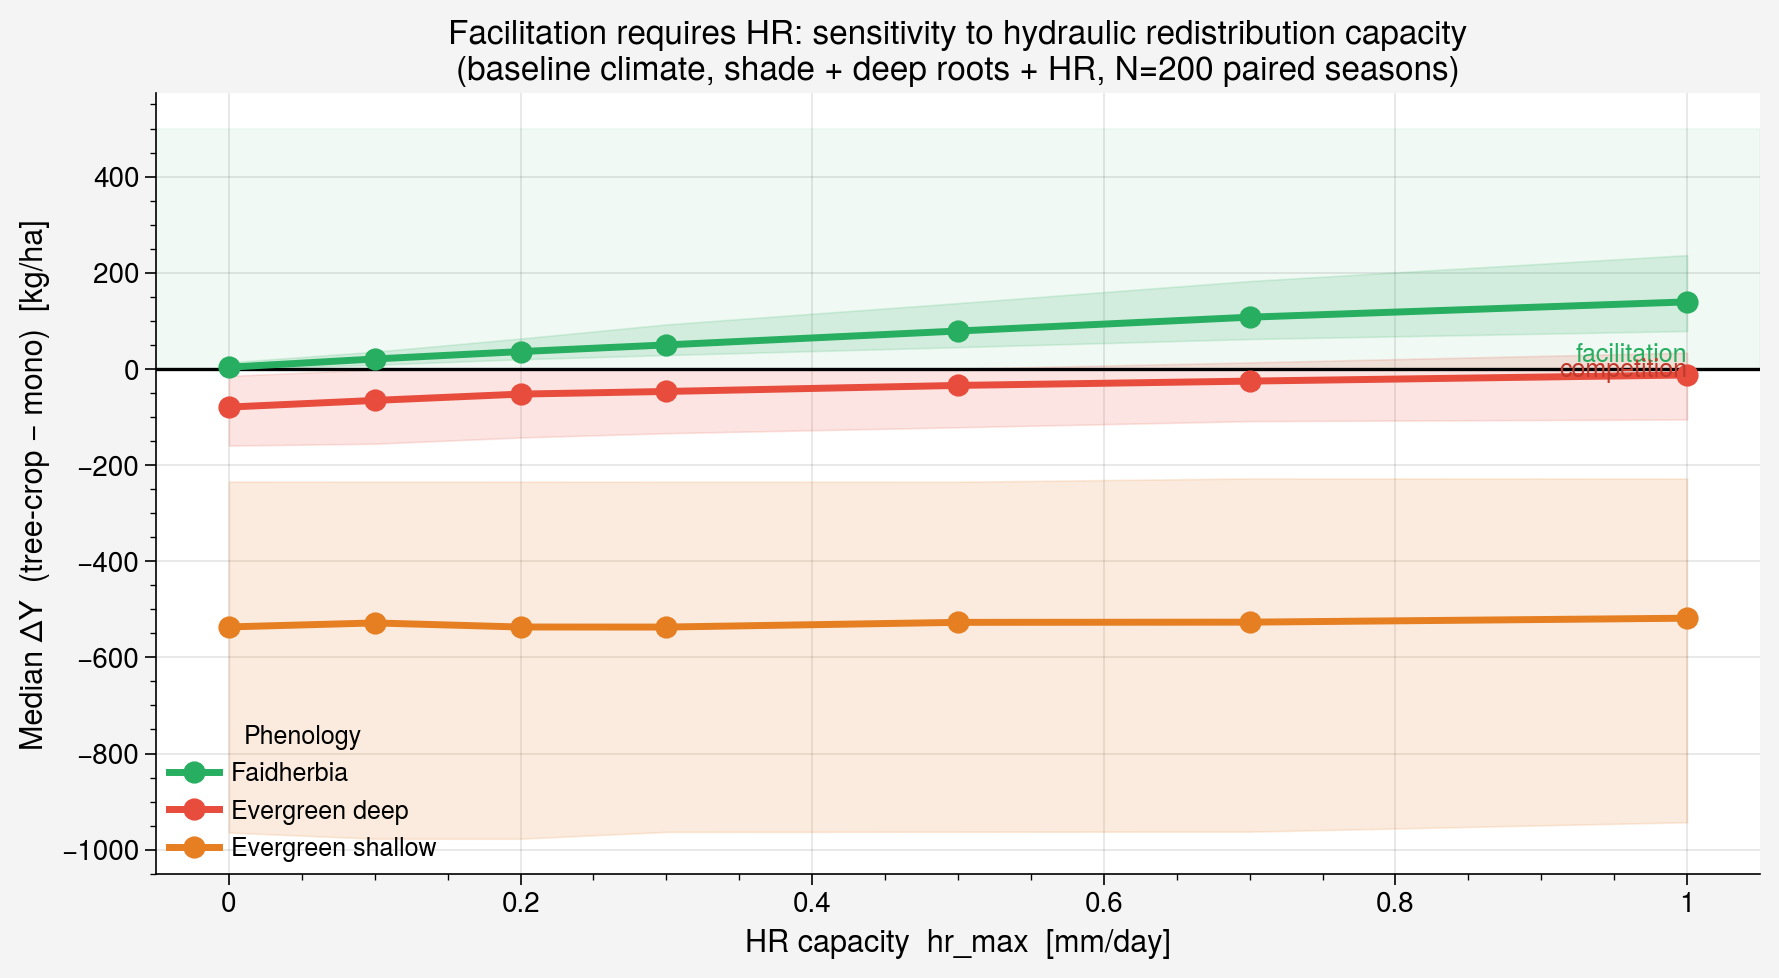


Median ΔY [IQR] by hr_max:
  Faidherbia:
    hr_max=0.0  →  +4 kg/ha  [-1, +14]
    hr_max=0.1  →  +21 kg/ha  [+8, +36]
    hr_max=0.2  →  +36 kg/ha  [+20, +63]
    hr_max=0.3  →  +50 kg/ha  [+29, +93]
    hr_max=0.5  →  +79 kg/ha  [+45, +137]
    hr_max=0.7  →  +108 kg/ha  [+62, +183]
    hr_max=1.0  →  +139 kg/ha  [+79, +237]
  Evergreen deep:
    hr_max=0.0  →  -79 kg/ha  [-160, -15]
    hr_max=0.1  →  -66 kg/ha  [-156, -1]
    hr_max=0.2  →  -52 kg/ha  [-143, +0]
    hr_max=0.3  →  -47 kg/ha  [-134, +0]
    hr_max=0.5  →  -34 kg/ha  [-121, +0]
    hr_max=0.7  →  -25 kg/ha  [-109, +13]
    hr_max=1.0  →  -13 kg/ha  [-105, +34]
  Evergreen shallow:
    hr_max=0.0  →  -537 kg/ha  [-964, -235]
    hr_max=0.1  →  -528 kg/ha  [-977, -235]
    hr_max=0.2  →  -537 kg/ha  [-977, -235]
    hr_max=0.3  →  -537 kg/ha  [-963, -235]
    hr_max=0.5  →  -527 kg/ha  [-963, -235]
    hr_max=0.7  →  -527 kg/ha  [-962, -228]
    hr_max=1.0  →  -519 kg/ha  [-943, -228]


In [19]:
N_HR     = 200
SEEDS_HR = list(range(N_HR))
HR_VALS  = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

print('Computing HR sensitivity sweep (N=200 per point)...')
t0 = time.time()

hr_results = {}
for arch_name, arch_params in ARCHETYPES.items():
    rows = []
    for hr_max in HR_VALS:
        dY = _dY_array(arch_params, _cli_ref, SEEDS_HR,
                       hr_max=hr_max,
                       shade_on=True, hr_on=True, deep_roots=True)
        rows.append([np.percentile(dY, 25), np.median(dY), np.percentile(dY, 75)])
    hr_results[arch_name] = np.array(rows)

print(f'Done in {time.time()-t0:.0f}s')

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color='k', lw=1.2, zorder=2)
ax.axhspan(0, 500, color='#d4efdf', alpha=0.35, zorder=1)

for arch_name, data in hr_results.items():
    p25, p50, p75 = data[:,0], data[:,1], data[:,2]
    ax.plot(HR_VALS, p50, color=COLORS[arch_name], lw=2.5, marker='o', ms=7,
            label=arch_name, zorder=3)
    ax.fill_between(HR_VALS, p25, p75, color=COLORS[arch_name], alpha=0.15, zorder=2)

ax.set_xlabel('HR capacity  hr_max  [mm/day]', fontsize=11)
ax.set_ylabel('Median \u0394Y  (tree-crop \u2212 mono)  [kg/ha]', fontsize=11)
ax.set_title('Facilitation requires HR: sensitivity to hydraulic redistribution capacity\n'
             '(baseline climate, shade + deep roots + HR, N=200 paired seasons)', fontsize=12)
ax.legend(title='Phenology', fontsize=9, title_fontsize=9)
ax.text(HR_VALS[-1], 15,  'facilitation', color='#27ae60', fontsize=9, ha='right')
ax.text(HR_VALS[-1], -15, 'competition',  color='#c0392b', fontsize=9, ha='right')
despine(ax)
plt.tight_layout()
plt.savefig('../output/fig4_hr_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMedian \u0394Y [IQR] by hr_max:')
for arch_name, data in hr_results.items():
    print(f'  {arch_name}:')
    for hr, row in zip(HR_VALS, data):
        print(f'    hr_max={hr:.1f}  \u2192  {row[1]:+.0f} kg/ha  [{row[0]:+.0f}, {row[2]:+.0f}]')


### Figure 5 — Pre-season deep-layer moisture sensitivity

**Question:** how much stored deep water does Faidherbia need to facilitate?

The model normally initialises the deep layer at field capacity (`s_deep_0 = s_fc`).
Sweep `s_deep_0` from near-dry (0.05) to s_fc. Full mechanism configuration.
N=200, baseline climate. IQR band = 25th–75th percentile.

s_fc = 0.690  (field capacity for loam)
Computing deep-layer moisture sensitivity sweep (N=200 per point)...


Done in 17s


/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 8320 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/cellaschnabel/miniforge3/envs/maize-Toff/lib/python3.10/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 8320 missing from current font.
  font.set_text(s, 0, flags=flags)


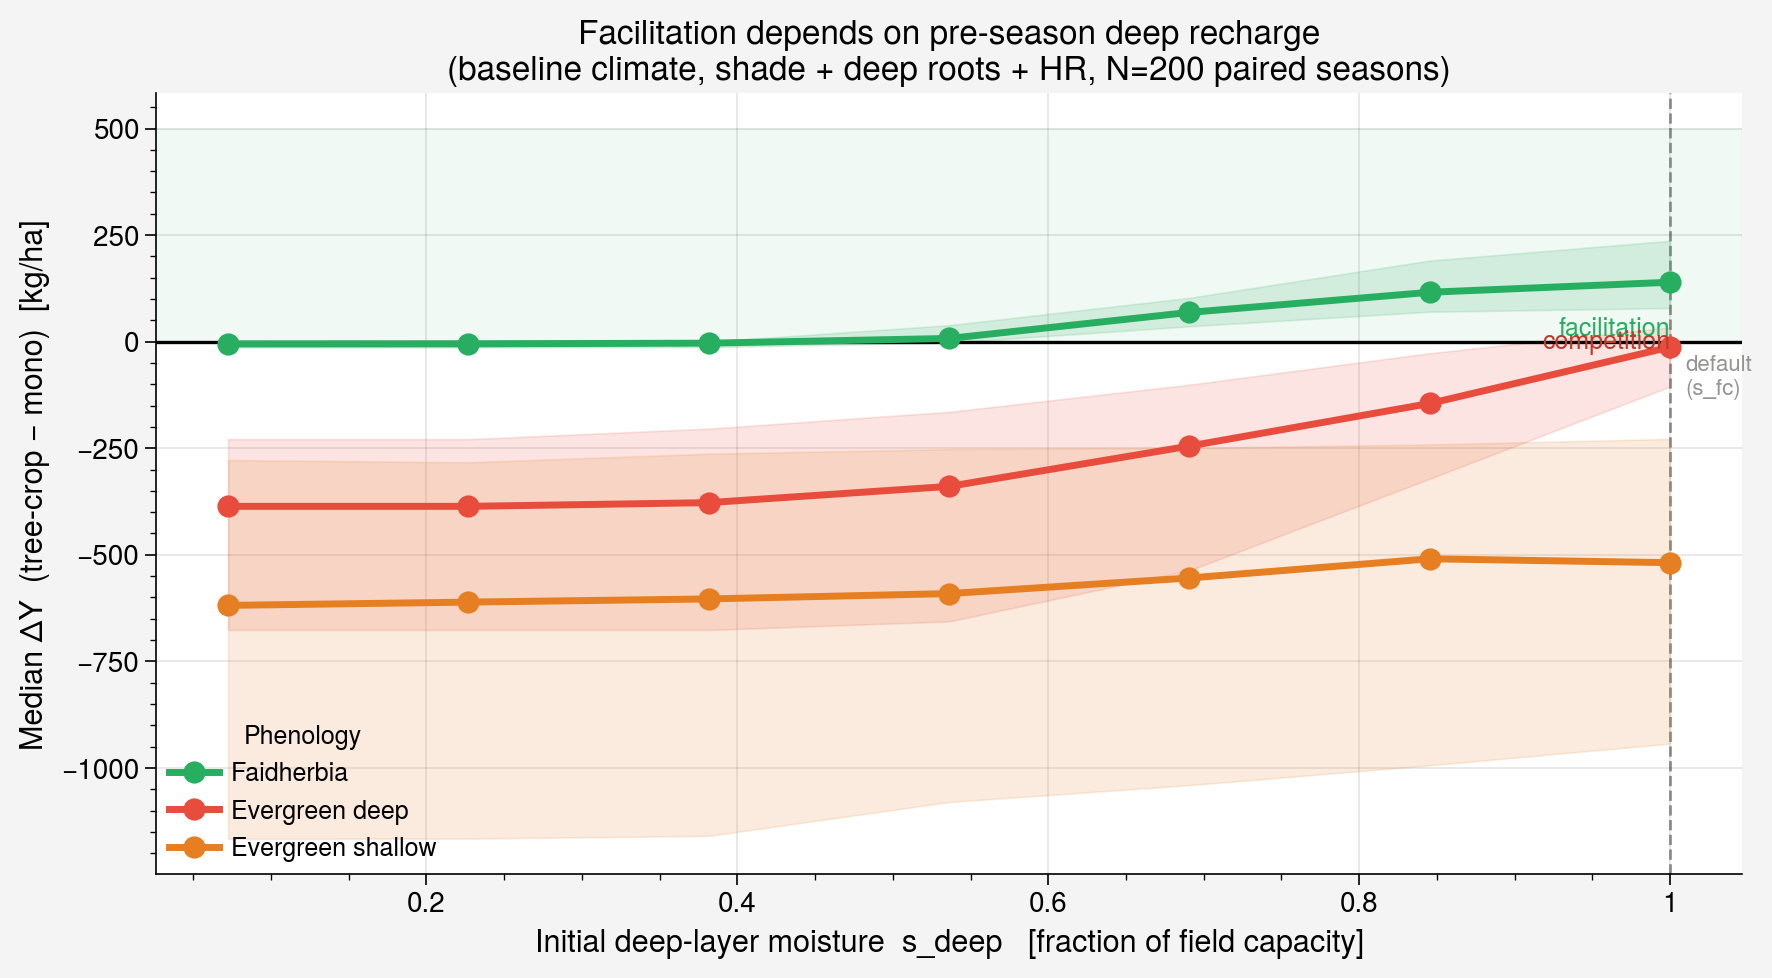


Median ΔY [IQR] by s_deep_0 (s_fc = 0.690):
  Faidherbia:
    s_deep_0/sfc=0.07  →  -5 kg/ha  [-14, +0]
    s_deep_0/sfc=0.23  →  -5 kg/ha  [-14, +0]
    s_deep_0/sfc=0.38  →  -4 kg/ha  [-13, +0]
    s_deep_0/sfc=0.54  →  +8 kg/ha  [-2, +39]
    s_deep_0/sfc=0.69  →  +69 kg/ha  [+36, +103]
    s_deep_0/sfc=0.85  →  +116 kg/ha  [+70, +190]
    s_deep_0/sfc=1.00  →  +139 kg/ha  [+79, +237]
  Evergreen deep:
    s_deep_0/sfc=0.07  →  -386 kg/ha  [-676, -229]
    s_deep_0/sfc=0.23  →  -386 kg/ha  [-676, -229]
    s_deep_0/sfc=0.38  →  -378 kg/ha  [-676, -204]
    s_deep_0/sfc=0.54  →  -340 kg/ha  [-656, -165]
    s_deep_0/sfc=0.69  →  -245 kg/ha  [-537, -101]
    s_deep_0/sfc=0.85  →  -145 kg/ha  [-321, -27]
    s_deep_0/sfc=1.00  →  -13 kg/ha  [-105, +34]
  Evergreen shallow:
    s_deep_0/sfc=0.07  →  -619 kg/ha  [-1166, -278]
    s_deep_0/sfc=0.23  →  -611 kg/ha  [-1166, -283]
    s_deep_0/sfc=0.38  →  -604 kg/ha  [-1159, -263]
    s_deep_0/sfc=0.54  →  -591 kg/ha  [-1080, -252]
    s_d

In [20]:
N_SDEP     = 200
SEEDS_SDEP = list(range(N_SDEP))
_soil_ref  = Soil(texture='loam')
S_DEEP_VALS = np.linspace(0.05, _soil_ref.sfc, 7)
S_DEEP_FRAC = S_DEEP_VALS / _soil_ref.sfc   # x-axis: fraction of s_fc

print(f's_fc = {_soil_ref.sfc:.3f}  (field capacity for loam)')
print('Computing deep-layer moisture sensitivity sweep (N=200 per point)...')
t0 = time.time()

sdep_results = {}
for arch_name, arch_params in ARCHETYPES.items():
    rows = []
    for s_deep_0 in S_DEEP_VALS:
        dY = _dY_array(arch_params, _cli_ref, SEEDS_SDEP,
                       s_deep_0=s_deep_0,
                       shade_on=True, hr_on=True, deep_roots=True)
        rows.append([np.percentile(dY, 25), np.median(dY), np.percentile(dY, 75)])
    sdep_results[arch_name] = np.array(rows)

print(f'Done in {time.time()-t0:.0f}s')

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color='k', lw=1.2, zorder=2)
ax.axhspan(0, 500, color='#d4efdf', alpha=0.35, zorder=1)
ax.axvline(1.0, color='gray', lw=1, ls='--', zorder=1)
ax.text(1.01, ax.get_ylim()[0] if False else -30, 'default\n(s_fc)',
        color='gray', fontsize=8, va='top')

for arch_name, data in sdep_results.items():
    p25, p50, p75 = data[:,0], data[:,1], data[:,2]
    ax.plot(S_DEEP_FRAC, p50, color=COLORS[arch_name], lw=2.5, marker='o', ms=7,
            label=arch_name, zorder=3)
    ax.fill_between(S_DEEP_FRAC, p25, p75, color=COLORS[arch_name], alpha=0.15, zorder=2)

ax.set_xlabel('Initial deep-layer moisture  s_deep\u2080  [fraction of field capacity]', fontsize=11)
ax.set_ylabel('Median \u0394Y  (tree-crop \u2212 mono)  [kg/ha]', fontsize=11)
ax.set_title('Facilitation depends on pre-season deep recharge\n'
             '(baseline climate, shade + deep roots + HR, N=200 paired seasons)', fontsize=12)
ax.legend(title='Phenology', fontsize=9, title_fontsize=9)
ax.text(S_DEEP_FRAC[-1], 15,  'facilitation', color='#27ae60', fontsize=9, ha='right')
ax.text(S_DEEP_FRAC[-1], -15, 'competition',  color='#c0392b', fontsize=9, ha='right')
despine(ax)
plt.tight_layout()
plt.savefig('../output/fig5_sdep_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMedian \u0394Y [IQR] by s_deep_0 (s_fc = {_soil_ref.sfc:.3f}):')
for arch_name, data in sdep_results.items():
    print(f'  {arch_name}:')
    for frac, row in zip(S_DEEP_FRAC, data):
        print(f'    s_deep_0/sfc={frac:.2f}  \u2192  {row[1]:+.0f} kg/ha  [{row[0]:+.0f}, {row[2]:+.0f}]')


### Figure 6 — Annual-cycle MAP sweep

**Question:** does facilitation survive when the deep-layer pre-season moisture is
endogenous rather than assumed full?

Run two back-to-back full years. Year 1 spins up the deep layer under real dry-season
tree water use (full 178-day pre-season). End-of-year-1 `s_deep` feeds year 2 as the
initial condition. Year 2 is the paired mono vs tree-crop comparison.

**Left panel:** ΔY vs mean seasonal rainfall — direct comparison with Fig 2
(which assumed `s_deep₀ = s_fc`).

**Right panel:** median `s_deep` at planting vs rainfall — reveals how much the
dry season depletes the reservoir as a function of climate. Co-season trees
deplete it through year-round transpiration; Faidherbia (reverse phenology)
is dormant during the crop season but still active in the dry season.

Computing annual-cycle MAP sweep (N=200 per archetype × scale)...


Done in 39s   (s_fc = 0.690)


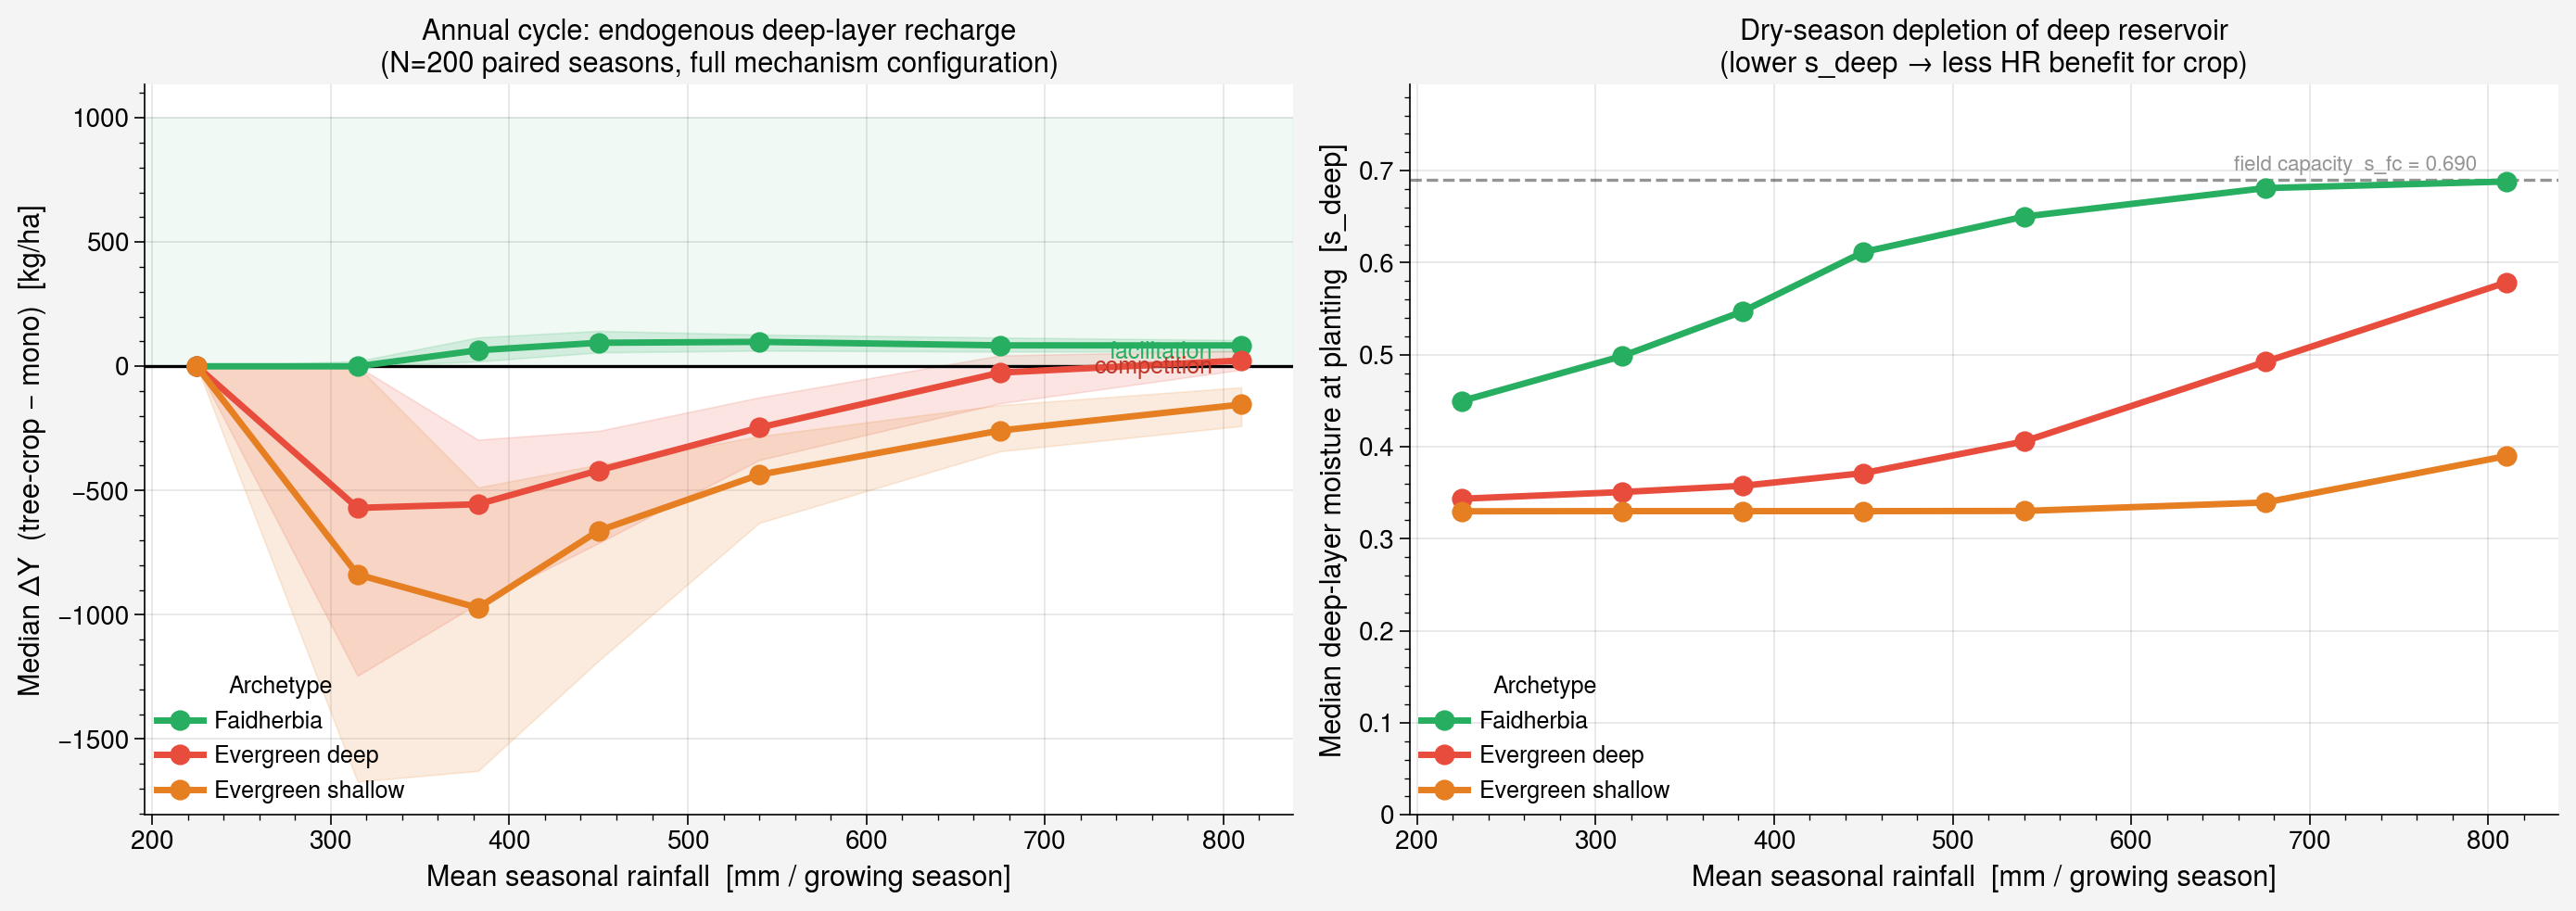


Median ΔY (annual cycle) vs Fig 2 (s_deep₀ = s_fc assumed):
  Faidherbia:
    225 mm/season  →  ΔY=+0 [+0,+0]  s_deep=0.450  (sfc=0.690)
    315 mm/season  →  ΔY=+0 [-1,+21]  s_deep=0.499  (sfc=0.690)
    382 mm/season  →  ΔY=+64 [+20,+116]  s_deep=0.547  (sfc=0.690)
    450 mm/season  →  ΔY=+95 [+56,+142]  s_deep=0.612  (sfc=0.690)
    540 mm/season  →  ΔY=+98 [+63,+128]  s_deep=0.650  (sfc=0.690)
    675 mm/season  →  ΔY=+84 [+59,+116]  s_deep=0.681  (sfc=0.690)
    810 mm/season  →  ΔY=+84 [+60,+106]  s_deep=0.688  (sfc=0.690)
  Evergreen deep:
    225 mm/season  →  ΔY=+0 [+0,+0]  s_deep=0.343  (sfc=0.690)
    315 mm/season  →  ΔY=-570 [-1245,+0]  s_deep=0.351  (sfc=0.690)
    382 mm/season  →  ΔY=-555 [-954,-295]  s_deep=0.358  (sfc=0.690)
    450 mm/season  →  ΔY=-419 [-711,-260]  s_deep=0.371  (sfc=0.690)
    540 mm/season  →  ΔY=-247 [-377,-125]  s_deep=0.406  (sfc=0.690)
    675 mm/season  →  ΔY=-25 [-149,+44]  s_deep=0.492  (sfc=0.690)
    810 mm/season  →  ΔY=+23 [-14,+62]  

In [21]:
N_ANN     = 200
SEEDS_ANN = list(range(N_ANN))
_soil_sfc = Soil(texture='loam').sfc

print("Computing annual-cycle MAP sweep (N=200 per archetype × scale)...")
t0 = time.time()

ann_results = {}   # arch_name → (dY_rows [n_scales,3], sdep_meds [n_scales])
for arch_name, arch_params in ARCHETYPES.items():
    dY_rows   = []   # [p25, median, p75] per scale
    sdep_meds = []   # median s_deep at planting per scale
    for scale in RF_SCALES:
        cli_ = Climate(
            alpha_r  = [a * scale for a in _cli_ref.alpha_r],
            lambda_r = _cli_ref.lambda_r,
            ET_max   = _cli_ref.ET_max,
        )
        dY, sdep = _dY_array_annual(arch_params, cli_, SEEDS_ANN,
                                    shade_on=True, hr_on=True, deep_roots=True)
        dY_rows.append([np.percentile(dY, 25), np.median(dY), np.percentile(dY, 75)])
        sdep_meds.append(np.median(sdep))
    ann_results[arch_name] = (np.array(dY_rows), np.array(sdep_meds))

print(f"Done in {time.time()-t0:.0f}s   (s_fc = {_soil_sfc:.3f})")

# ── Figure 6: two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes

# Left: ΔY vs seasonal rainfall (mirrors Fig 2 axes for direct comparison)
ax1.axhline(0, color='k', lw=1.2, zorder=2)
ax1.axhspan(0, 1000, color='#d4efdf', alpha=0.35, zorder=1)

for arch_name, (dY_rows, sdep_meds) in ann_results.items():
    p25, p50, p75 = dY_rows[:,0], dY_rows[:,1], dY_rows[:,2]
    ax1.plot(SEASON_RAIN_mm, p50, color=COLORS[arch_name], lw=2.5, marker='o', ms=7,
             label=arch_name, zorder=3)
    ax1.fill_between(SEASON_RAIN_mm, p25, p75,
                     color=COLORS[arch_name], alpha=0.15, zorder=2)

ax1.set_xlabel('Mean seasonal rainfall  [mm / growing season]', fontsize=11)
ax1.set_ylabel('Median \u0394Y  (tree-crop \u2212 mono)  [kg/ha]', fontsize=11)
ax1.set_title('Annual cycle: endogenous deep-layer recharge\n'
              '(N=200 paired seasons, full mechanism configuration)', fontsize=11)
ax1.legend(title='Archetype', fontsize=9, title_fontsize=9)
ax1.text(SEASON_RAIN_mm[-1]*0.98,  30, 'facilitation', color='#27ae60', fontsize=9, ha='right')
ax1.text(SEASON_RAIN_mm[-1]*0.98, -30, 'competition',  color='#c0392b', fontsize=9, ha='right')
despine(ax1)

# Right: median s_deep at planting vs rainfall
ax2.axhline(_soil_sfc, color='gray', lw=1.2, ls='--', zorder=1)
ax2.text(SEASON_RAIN_mm[-1]*0.98, _soil_sfc + 0.005,
         f'field capacity  s_fc = {_soil_sfc:.3f}',
         color='gray', fontsize=8, ha='right', va='bottom')

for arch_name, (dY_rows, sdep_meds) in ann_results.items():
    ax2.plot(SEASON_RAIN_mm, sdep_meds, color=COLORS[arch_name], lw=2.5, marker='o', ms=7,
             label=arch_name, zorder=3)

ax2.set_xlabel('Mean seasonal rainfall  [mm / growing season]', fontsize=11)
ax2.set_ylabel('Median deep-layer moisture at planting  [s_deep]', fontsize=11)
ax2.set_title('Dry-season depletion of deep reservoir\n'
              '(lower s_deep \u2192 less HR benefit for crop)', fontsize=11)
ax2.legend(title='Archetype', fontsize=9, title_fontsize=9)
ax2.set_ylim(0, _soil_sfc * 1.15)
despine(ax2)

plt.tight_layout()
plt.savefig('../output/fig6_annual_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMedian \u0394Y (annual cycle) vs Fig 2 (s_deep\u2080 = s_fc assumed):")
for arch_name, (dY_rows, sdep_meds) in ann_results.items():
    print(f"  {arch_name}:")
    for sr, row, sdep in zip(SEASON_RAIN_mm, dY_rows, sdep_meds):
        print(f"    {sr:.0f} mm/season  \u2192  \u0394Y={row[1]:+.0f} [{row[0]:+.0f},{row[2]:+.0f}]  "
              f"s_deep={sdep:.3f}  (sfc={_soil_sfc:.3f})")

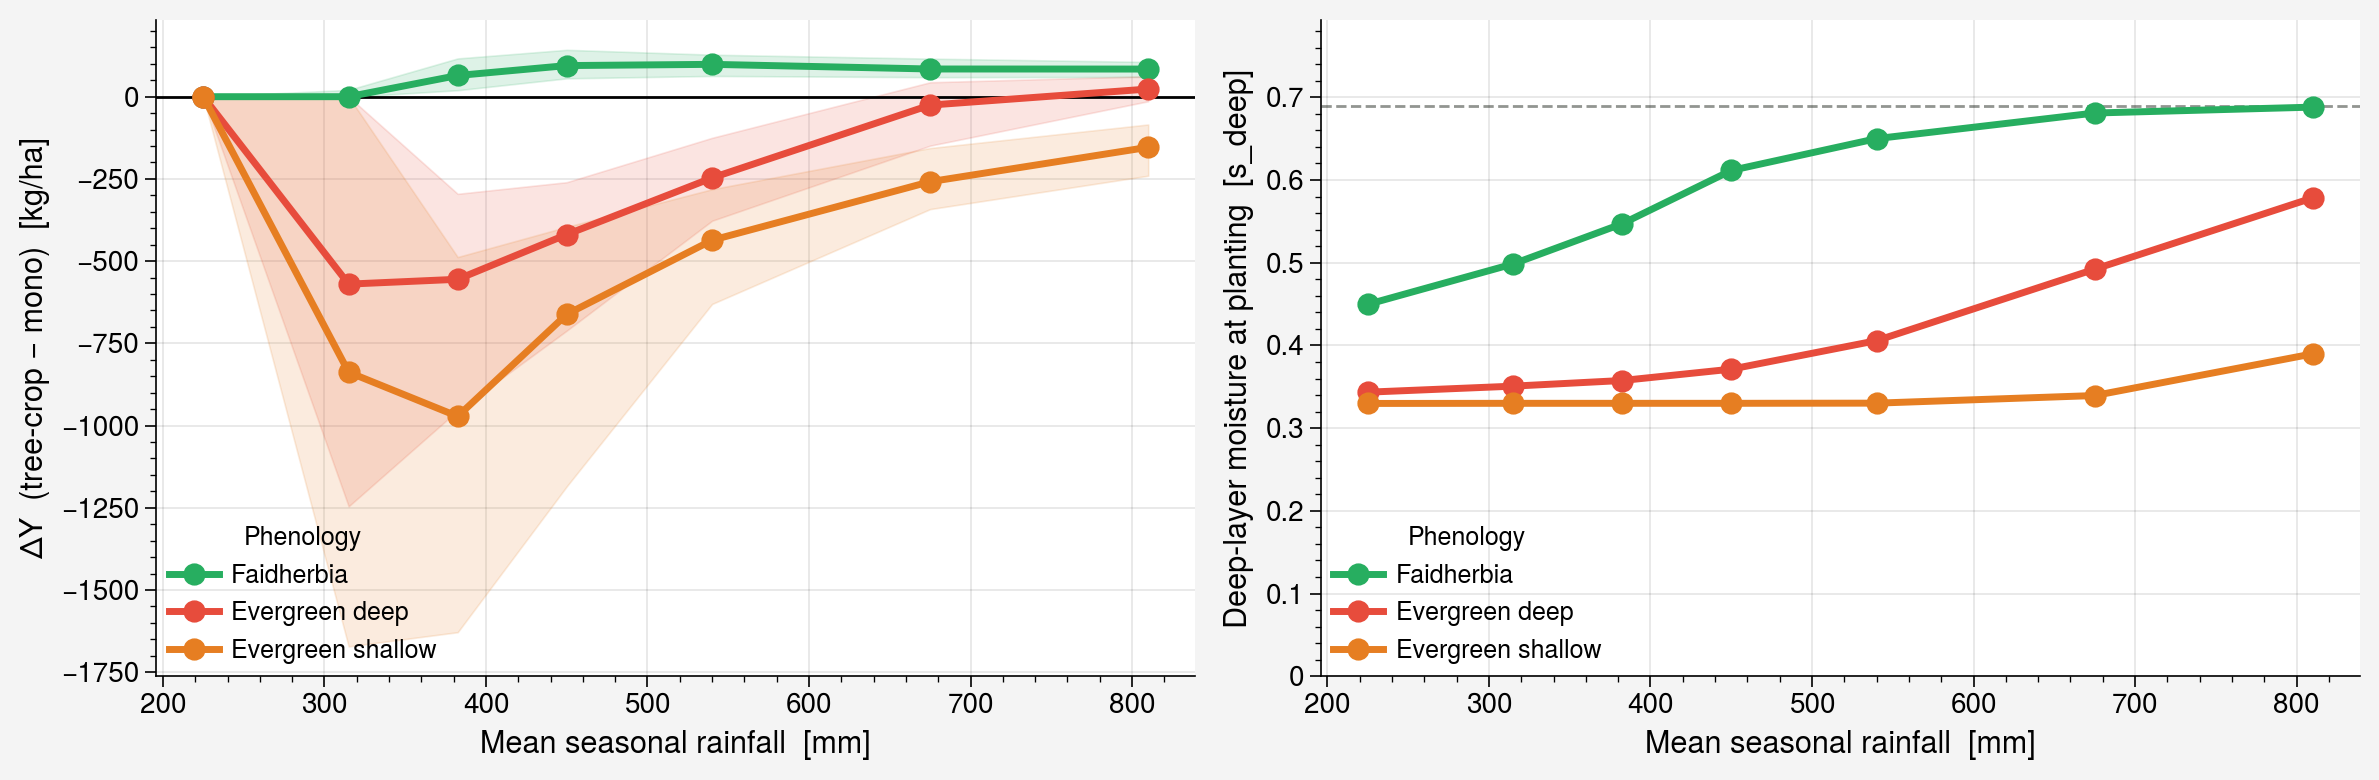

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1, ax2 = axes

# Left: ΔY
ax1.axhline(0, color='k', lw=1, zorder=2)
for arch_name, (dY_rows, sdep_meds) in ann_results.items():
    p25, p50, p75 = dY_rows[:,0], dY_rows[:,1], dY_rows[:,2]
    ax1.plot(SEASON_RAIN_mm, p50, color=COLORS[arch_name], lw=2.5,
             marker='o', ms=7, label=arch_name, zorder=3)
    ax1.fill_between(SEASON_RAIN_mm, p25, p75,
                     color=COLORS[arch_name], alpha=0.15, zorder=2)
ax1.set_xlabel('Mean seasonal rainfall  [mm]', fontsize=11)
ax1.set_ylabel('ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
ax1.legend(title='Phenology', fontsize=9, title_fontsize=9, frameon=False)
despine(ax1)

# Right: s_deep at planting
ax2.axhline(_soil_sfc, color='gray', lw=1, ls='--', zorder=1)
for arch_name, (dY_rows, sdep_meds) in ann_results.items():
    ax2.plot(SEASON_RAIN_mm, sdep_meds, color=COLORS[arch_name], lw=2.5,
             marker='o', ms=7, label=arch_name, zorder=3)
ax2.set_xlabel('Mean seasonal rainfall  [mm]', fontsize=11)
ax2.set_ylabel('Deep-layer moisture at planting  [s_deep]', fontsize=11)
ax2.set_ylim(0, _soil_sfc * 1.15)
ax2.legend(title='Phenology', fontsize=9, title_fontsize=9, frameon=False)
despine(ax2)

plt.tight_layout()
plt.savefig('../output/fig6_annual_cycle_simple.png', dpi=150, bbox_inches='tight')
plt.show()